<a href="https://colab.research.google.com/github/luiscaaa/TDG_inventarios/blob/main/modelo_final_inventarios.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# **Pronóstico de consumos MRO por tipo de serie**

# **1. Configuración del proyecto y auditoría inicial de las series**

> **Finalidad de la sección.**  
> Esta etapa establece la base técnica del cuaderno: organiza la carga del dataset consolidado, valida la estructura temporal, identifica la vida activa de cada SKU y clasifica las series según su patrón de demanda para orientar la selección posterior de modelos de pronóstico.

---

### Alcance metodológico

La auditoría inicial se formula para responder cuatro preguntas:

1. ¿El calendario mensual es continuo y consistente?
2. ¿Desde qué momento cada serie entra realmente en vida activa?
3. ¿La demanda observada corresponde a un patrón **estable** o **intermitente**?
4. ¿La clasificación empírica coincide con la tipología declarada en el nombre de la serie?

---

### Base cuantitativa de la clasificación ADI/CV²

La clasificación de Syntetos-Boylan se emplea para distinguir entre series con demanda regular y series con presencia estructural de ceros. Para una serie mensual observada en su vida activa:

$$
ADI = \frac{T}{N_{+}}
$$

$$
CV^2 = \left(\frac{s_{+}}{\bar{D}_{+}}\right)^2
$$

donde:

| Símbolo | Interpretación |
|---|---|
| $T$ | Número total de periodos observados en vida activa |
| $N_{+}$ | Número de periodos con demanda estrictamente positiva |
| $\bar{D}_{+}$ | Media de las demandas no nulas |
| $s_{+}$ | Desviación estándar de las demandas no nulas |

---

### Regla de clasificación utilizada

| Categoría | Condición sobre $ADI$ | Condición sobre $CV^2$ | Interpretación operativa |
|---|---:|---:|---|
| **Estable** | $ADI < 1.32$ | $CV^2 < 0.49$ | Consumo relativamente frecuente y de magnitud controlada |
| **Intermitente** | $ADI \geq 1.32$ | $CV^2 < 0.49$ | Presencia recurrente de meses en cero, con tamaños de demanda comparativamente menos dispersos |
| **Errática** | $ADI < 1.32$ | $CV^2 \geq 0.49$ | Consumo frecuente, pero con montos altamente variables |
| **Irregular** | $ADI \geq 1.32$ | $CV^2 \geq 0.49$ | Demanda espaciada y además variable en magnitud |

---

### Criterio de uso en el cuaderno

La clasificación empírica se utilizará como **insumo de decisión** para separar las familias de modelado:

- Las series **estables** alimentarán el bloque **smooth**.
- Las series **intermitentes** e **irregulares** alimentarán el bloque **sparse/intermittent**.
- Los valores faltantes previos al arranque real de una serie **no** se tratarán como demanda cero, sino como ausencia estructural antes de la vida activa del ítem.

## Criterios de auditoría, trazabilidad y consistencia analítica

La rutina computacional de esta sección revisa simultáneamente la estructura del archivo, la coherencia temporal y el comportamiento de cada serie antes de iniciar cualquier ajuste de modelos.

### Componentes verificados

| Componente | Revisión aplicada | Criterio técnico | Implicación para el pronóstico |
|---|---|---|---|
| **Calendario mensual** | Orden cronológico y continuidad de fechas | Secuencia mensual sin saltos no explicados | Evita distorsiones en rezagos, estacionalidad y validación temporal |
| **Variables exógenas** | Presencia de temperatura, precipitación y TRM | Existencia de columnas obligatorias | Permite construir posteriormente modelos condicionales tipo SARIMAX |
| **Vida activa de cada SKU** | Recorte desde el primer dato no nulo | Separación entre ausencia estructural y demanda cero | Evita inflar artificialmente la intermitencia |
| **Ceros en vida activa** | Cálculo del porcentaje de meses con consumo cero | Medición directa de esparsidad | Ayuda a justificar el uso de modelos especializados |
| **Clasificación ADI/CV²** | Estimación por serie | Regla de Syntetos-Boylan | Define la ruta metodológica de modelado |
| **Coherencia nombre–patrón** | Comparación entre sufijo y categoría empírica | Concordancia entre tipología declarada y observada | Permite detectar series mal etiquetadas o ambiguas |

---

### Convención de lectura adoptada

- El sufijo `_smooth` se interpreta como una serie candidata a modelos para demanda continua.
- El sufijo `_intermittent` se interpreta como una serie candidata a modelos para demanda esporádica.
- La auditoría empírica funciona como **mecanismo de control interno**: si el nombre y el patrón no coinciden, la serie queda marcada para revisión.

---

> **Nota metodológica.**  
> Esta etapa no ajusta todavía modelos de pronóstico. Su función es depurar la lógica del problema, justificar la separación de familias y dejar evidencia técnica reproducible sobre la naturaleza estadística de cada serie.

,n_filas,fecha_min,fecha_max,n_series_objetivo,n_series_smooth,n_series_sparse,n_exogenas,horizonte_pronostico_meses,periodos_mensuales_esperados,periodos_mensuales_faltantes
0,84,2019-01-01,2025-12-01,6,3,3,3,12,84,0


,serie,grupo_nombre,inicio_vida_activa,fin_serie,n_obs_activas,pct_ceros_vida_activa,ADI,CV2,categoria_ADI_CV2,coherencia_nombre_vs_patron,media,desv_std,min,max
0,ISM10001_smooth,Smooth,2019-01-01,2025-12-01,84,0.0%,1.000,0.319,Estable,Sí,62.23,35.15,12.45,177.22
1,ISM10003_smooth,Smooth,2019-01-01,2025-12-01,84,0.0%,1.000,0.115,Estable,Sí,383.68,130.08,24.48,741.52
2,ISM10006_smooth,Smooth,2019-07-01,2025-12-01,78,0.0%,1.000,0.199,Estable,Sí,"2,599.68","1,160.68",511.78,"7,262.85"
3,ICP10107_intermittent,Sparse,2020-12-01,2025-12-01,61,60.7%,2.542,0.262,Intermitente,Sí,47.30,70.41,0.00,250.00
4,ICP10095_intermittent,Sparse,2021-09-01,2025-12-01,52,69.2%,3.250,0.635,Irregular,Sí,1.13,2.34,0.00,12.00
5,ICP10360_intermittent,Sparse,2021-12-01,2025-12-01,49,69.4%,3.267,0.450,Intermitente,Sí,0.63,1.22,0.00,6.00


,categoria_ADI_CV2,n_series,pct_ceros_promedio,adi_promedio,cv2_promedio
0,Estable,3,0.0%,1.000,0.211
1,Intermitente,2,65.0%,2.904,0.356
2,Irregular,1,69.2%,3.250,0.635


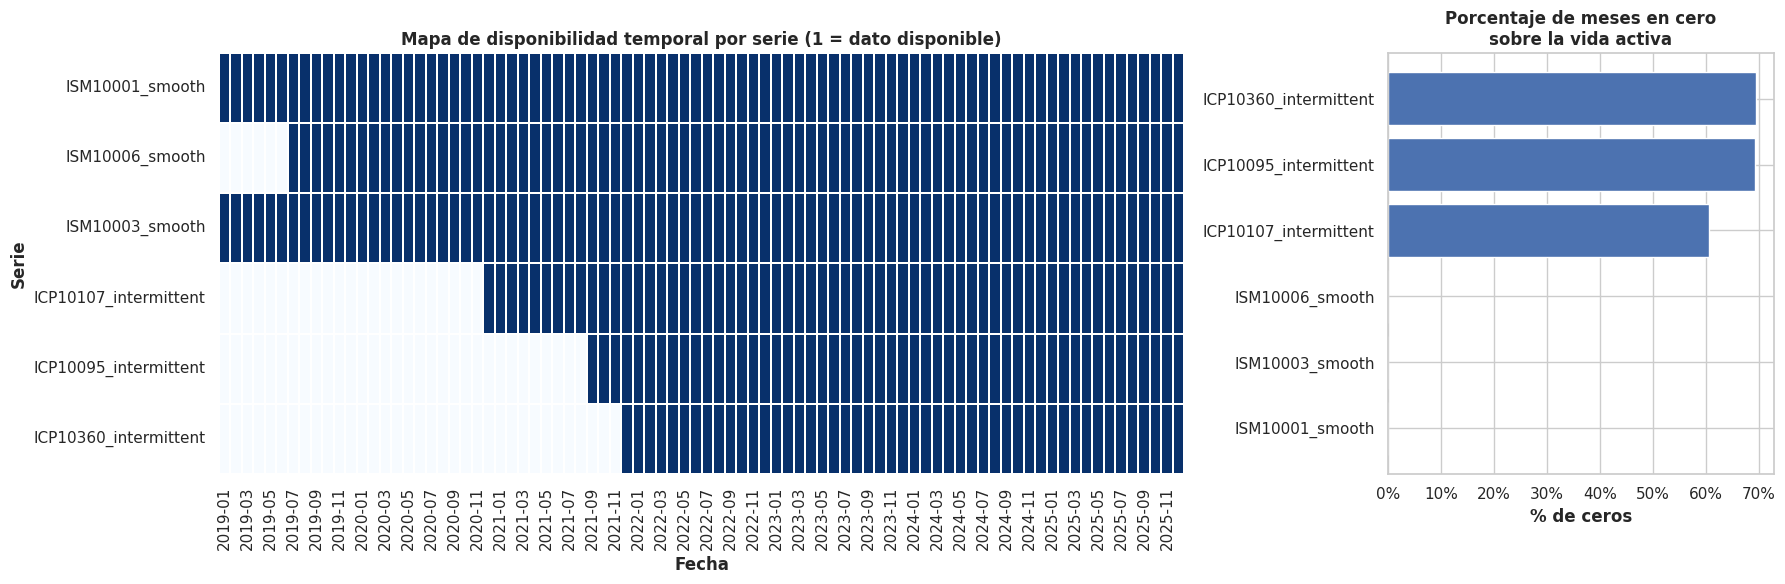

Archivo utilizado: /content/dataset_consolidado.xlsx
Series objetivo detectadas: 6
Series smooth detectadas por nombre: 3
Series sparse detectadas por nombre: 3
Calendario mensual continuo: sí.


In [ ]:
# ============================================================
# SECCIÓN 1 | Configuración, carga y auditoría inicial
# ============================================================
import warnings
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from IPython.display import display

try:
    from google.colab import files
except Exception:
    files = None

warnings.filterwarnings("ignore")

pd.set_option("display.max_columns", 200)
pd.set_option("display.float_format", lambda x: f"{x:,.4f}")

sns.set_theme(style="whitegrid", context="notebook")
plt.rcParams["figure.figsize"] = (14, 5)
plt.rcParams["axes.titleweight"] = "bold"
plt.rcParams["axes.labelweight"] = "bold"

# ---------------------------
# Parámetros globales
# ---------------------------
DATE_COL = "fecha"
EXOG_COLS = ["temp_media_c", "precipitacion_mm", "trm_promedio"]
SEASONAL_PERIOD = 12
FORECAST_HORIZON = 12

# ---------------------------
# Localización robusta del archivo
# ---------------------------
def locate_dataset(filename="dataset_consolidado.xlsx"):
    candidates = [
        Path("/content") / filename,
        Path("/mnt/data") / filename,
        Path(filename),
    ]
    for path in candidates:
        if path.exists():
            return str(path)

    if files is None:
        raise FileNotFoundError(f"No se encontró '{filename}' en el entorno actual.")

    print(f"No se encontró '{filename}'. Se habilita la carga manual.")
    uploaded = files.upload()
    selected = filename if filename in uploaded else next(iter(uploaded))
    return f"/content/{selected}"

# ---------------------------
# Funciones auxiliares
# ---------------------------
def active_slice(data, col):
    first_idx = data[col].first_valid_index()
    if first_idx is None:
        return data.iloc[0:0].copy()
    return data.loc[first_idx:, [DATE_COL, col] + EXOG_COLS].reset_index(drop=True)

def adi_cv2(y):
    y = pd.Series(y).dropna().astype(float)

    if y.empty:
        return np.nan, np.nan, "Sin datos"

    non_zero = y[y > 0]
    adi = np.inf if len(non_zero) == 0 else len(y) / len(non_zero)

    if len(non_zero) == 0:
        cv2 = np.nan
    elif len(non_zero) == 1:
        cv2 = 0.0
    else:
        mean_nz = non_zero.mean()
        cv2 = ((non_zero.std(ddof=1) / mean_nz) ** 2) if mean_nz != 0 else np.nan

    if np.isinf(adi):
        category = "Sin demanda"
    elif adi < 1.32 and cv2 < 0.49:
        category = "Estable"
    elif adi >= 1.32 and cv2 < 0.49:
        category = "Intermitente"
    elif adi < 1.32 and cv2 >= 0.49:
        category = "Errática"
    else:
        category = "Irregular"

    return float(adi), float(cv2) if pd.notna(cv2) else np.nan, category

def expected_group_from_name(series_name):
    return "Smooth" if series_name.endswith("_smooth") else "Sparse"

def empirical_group_from_category(category):
    return "Smooth" if category == "Estable" else "Sparse"

def base_style(styler, caption):
    return (
        styler
        .set_caption(caption)
        .set_table_styles([
            {"selector": "caption", "props": [("font-size", "14px"), ("font-weight", "bold")]},
            {"selector": "th", "props": [("background-color", "#16324f"), ("color", "white"), ("text-align", "center")]},
            {"selector": "td", "props": [("text-align", "center")]},
        ])
    )

# ---------------------------
# Carga del dataset
# ---------------------------
dataset_path = locate_dataset("dataset_consolidado.xlsx")
df = pd.read_excel(dataset_path)
df.columns = [str(c).strip() for c in df.columns]

if DATE_COL not in df.columns:
    raise ValueError(f"No se encontró la columna temporal obligatoria '{DATE_COL}'.")

missing_exog = [c for c in EXOG_COLS if c not in df.columns]
if missing_exog:
    raise ValueError(f"Faltan columnas exógenas obligatorias: {missing_exog}")

df[DATE_COL] = pd.to_datetime(df[DATE_COL])
df = df.sort_values(DATE_COL).reset_index(drop=True)

TARGET_COLS = [c for c in df.columns if c not in [DATE_COL] + EXOG_COLS]
SMOOTH_COLS = [c for c in TARGET_COLS if c.endswith("_smooth")]
SPARSE_COLS = [c for c in TARGET_COLS if c.endswith("_intermittent")]

# ---------------------------
# Resumen estructural
# ---------------------------
full_calendar = pd.date_range(df[DATE_COL].min(), df[DATE_COL].max(), freq="MS")
missing_periods = full_calendar.difference(df[DATE_COL])

summary_df = pd.DataFrame({
    "n_filas": [len(df)],
    "fecha_min": [df[DATE_COL].min()],
    "fecha_max": [df[DATE_COL].max()],
    "n_series_objetivo": [len(TARGET_COLS)],
    "n_series_smooth": [len(SMOOTH_COLS)],
    "n_series_sparse": [len(SPARSE_COLS)],
    "n_exogenas": [len(EXOG_COLS)],
    "horizonte_pronostico_meses": [FORECAST_HORIZON],
    "periodos_mensuales_esperados": [len(full_calendar)],
    "periodos_mensuales_faltantes": [len(missing_periods)],
})

display(
    base_style(
        summary_df.style.format({
            "fecha_min": lambda x: x.strftime("%Y-%m-%d"),
            "fecha_max": lambda x: x.strftime("%Y-%m-%d"),
        }),
        "Resumen estructural del dataset"
    )
)

# ---------------------------
# Auditoría ADI/CV² por serie
# ---------------------------
audit_rows = []

for col in TARGET_COLS:
    active = active_slice(df, col)

    if active.empty:
        audit_rows.append({
            "serie": col,
            "grupo_nombre": expected_group_from_name(col),
            "inicio_vida_activa": pd.NaT,
            "fin_serie": pd.NaT,
            "n_obs_activas": 0,
            "pct_ceros_vida_activa": np.nan,
            "ADI": np.nan,
            "CV2": np.nan,
            "categoria_ADI_CV2": "Sin datos",
            "coherencia_nombre_vs_patron": "Revisar",
            "media": np.nan,
            "desv_std": np.nan,
            "min": np.nan,
            "max": np.nan,
        })
        continue

    adi, cv2, category = adi_cv2(active[col])
    expected_group = expected_group_from_name(col)
    empirical_group = empirical_group_from_category(category)

    audit_rows.append({
        "serie": col,
        "grupo_nombre": expected_group,
        "inicio_vida_activa": active[DATE_COL].min(),
        "fin_serie": active[DATE_COL].max(),
        "n_obs_activas": int(active[col].notna().sum()),
        "pct_ceros_vida_activa": float((active[col] == 0).mean()),
        "ADI": adi,
        "CV2": cv2,
        "categoria_ADI_CV2": category,
        "coherencia_nombre_vs_patron": "Sí" if expected_group == empirical_group else "Revisar",
        "media": float(active[col].mean()),
        "desv_std": float(active[col].std(ddof=1)),
        "min": float(active[col].min()),
        "max": float(active[col].max()),
    })

audit_df = pd.DataFrame(audit_rows).sort_values("inicio_vida_activa").reset_index(drop=True)

audit_style = (
    audit_df.style
    .format({
        "inicio_vida_activa": lambda x: x.strftime("%Y-%m-%d") if pd.notna(x) else "",
        "fin_serie": lambda x: x.strftime("%Y-%m-%d") if pd.notna(x) else "",
        "pct_ceros_vida_activa": "{:.1%}",
        "ADI": "{:.3f}",
        "CV2": "{:.3f}",
        "media": "{:,.2f}",
        "desv_std": "{:,.2f}",
        "min": "{:,.2f}",
        "max": "{:,.2f}",
    })
    .background_gradient(subset=["pct_ceros_vida_activa"], cmap="YlOrRd")
    .background_gradient(subset=["ADI", "CV2"], cmap="PuBu")
    .apply(
        lambda s: [
            "background-color: #d9ead3; font-weight: bold;" if v == "Sí"
            else "background-color: #f4cccc; font-weight: bold;"
            for v in s
        ],
        subset=["coherencia_nombre_vs_patron"]
    )
)

display(base_style(audit_style, "Auditoría de demanda por SKU en vida activa"))

# ---------------------------
# Resumen por familia empírica
# ---------------------------
family_df = (
    audit_df.groupby("categoria_ADI_CV2", dropna=False)
    .agg(
        n_series=("serie", "count"),
        pct_ceros_promedio=("pct_ceros_vida_activa", "mean"),
        adi_promedio=("ADI", "mean"),
        cv2_promedio=("CV2", "mean")
    )
    .reset_index()
    .sort_values(["n_series", "categoria_ADI_CV2"], ascending=[False, True])
)

display(
    base_style(
        family_df.style.format({
            "pct_ceros_promedio": "{:.1%}",
            "adi_promedio": "{:.3f}",
            "cv2_promedio": "{:.3f}",
        }),
        "Resumen por familia empírica de demanda"
    )
)

# ---------------------------
# Visualización compacta de apoyo
# ---------------------------
availability = pd.DataFrame(
    {col: df[col].notna().astype(int).values for col in TARGET_COLS},
    index=df[DATE_COL].dt.strftime("%Y-%m")
).T

plot_df = audit_df.sort_values("pct_ceros_vida_activa", ascending=True).copy()

fig, axes = plt.subplots(1, 2, figsize=(18, 6), gridspec_kw={"width_ratios": [2.5, 1]})

sns.heatmap(availability, cmap="Blues", cbar=False, linewidths=0.15, linecolor="white", ax=axes[0])
axes[0].set_title("Mapa de disponibilidad temporal por serie (1 = dato disponible)")
axes[0].set_xlabel("Fecha")
axes[0].set_ylabel("Serie")
axes[0].tick_params(axis="x", rotation=90)
axes[0].tick_params(axis="y", rotation=0)

axes[1].barh(plot_df["serie"], plot_df["pct_ceros_vida_activa"])
axes[1].set_title("Porcentaje de meses en cero\nsobre la vida activa")
axes[1].set_xlabel("% de ceros")
axes[1].set_ylabel("")
axes[1].xaxis.set_major_formatter(plt.FuncFormatter(lambda x, pos: f"{x:.0%}"))

plt.tight_layout()
plt.show()

print(f"Archivo utilizado: {dataset_path}")
print(f"Series objetivo detectadas: {len(TARGET_COLS)}")
print(f"Series smooth detectadas por nombre: {len(SMOOTH_COLS)}")
print(f"Series sparse detectadas por nombre: {len(SPARSE_COLS)}")

if len(missing_periods) == 0:
    print("Calendario mensual continuo: sí.")
else:
    print("Calendario mensual continuo: no.")
    print("Periodos faltantes:", [p.strftime("%Y-%m") for p in missing_periods])

# **2. Exploración visual, estacionalidad y diagnóstico econométrico preliminar**

> **Propósito técnico.**  
> Esta sección examina la estructura estadística de las series antes del modelado. La finalidad no consiste todavía en seleccionar un modelo ganador, sino en documentar si existen señales de tendencia, estacionalidad mensual, persistencia serial, concentración de ceros y asociación preliminar con variables exógenas.

---

## 2.1. Preguntas analíticas de la sección

La revisión previa al ajuste busca responder los siguientes interrogantes:

1. ¿La trayectoria histórica exhibe cambios de nivel, tendencia o ciclos visibles?
2. ¿La distribución mensual del consumo sugiere concentración estacional?
3. ¿La serie parece estacionaria en nivel o requiere diferenciación?
4. ¿Existe evidencia de memoria serial útil para modelos autoregresivos?
5. ¿Las variables exógenas muestran relación contemporánea o rezagada con la demanda?
6. ¿Las exógenas presentan colinealidad que deba vigilarse en modelos condicionales?

---

## 2.2. Estructura del diagnóstico

| Bloque de revisión | Herramientas aplicadas | Finalidad analítica |
|---|---|---|
| **Revisión visual global** | series históricas y trazado de exógenas | identificar tendencia, rupturas, oscilaciones y rango operativo |
| **Distribución y estacionalidad** | boxplot mensual e histograma | revisar concentración mensual, dispersión y asimetría |
| **Descomposición** | STL robusta | separar tendencia, componente estacional y residuo |
| **Estacionariedad** | pruebas ADF y KPSS | evaluar si la serie requiere diferenciación en nivel |
| **Persistencia temporal** | ACF y PACF | detectar rezagos relevantes para especificación SARIMAX |
| **Exogeneidad práctica** | correlaciones de Spearman y VIF | revisar utilidad y redundancia de variables externas |

---

## 2.3. Descomposición estructural

Para las series con longitud suficiente, la serie observada se representa mediante una descomposición aditiva:

$$
y_t = T_t + S_t + R_t
$$

donde:

| Componente | Interpretación |
|---|---|
| $T_t$ | tendencia de mediano plazo |
| $S_t$ | componente estacional |
| $R_t$ | componente residual o irregular |

La intensidad estacional se resume mediante:

$$
F_S = \max \left(0,\ 1 - \frac{\operatorname{Var}(R_t)}{\operatorname{Var}(S_t + R_t)} \right)
$$

Un valor alto de $F_S$ sugiere que la estacionalidad explica una fracción relevante de la variabilidad total.

---

## 2.4. Criterio preliminar para diferenciación

La sugerencia automática de diferenciación en nivel se apoya en dos contrastes complementarios:

- **ADF** con hipótesis nula de raíz unitaria.
- **KPSS** con hipótesis nula de estacionariedad.

La regla operativa se resume así:

$$
d_{\text{sugerido}} =
\begin{cases}
1, & \text{si ADF no rechaza raíz unitaria o KPSS rechaza estacionariedad} \\
0, & \text{en otro caso}
\end{cases}
$$

Para la componente estacional se adopta un criterio exploratorio:

$$
D_{\text{sugerido}} =
\begin{cases}
1, & \text{si la fuerza estacional es apreciable y la autocorrelación en } 12 \text{ meses es relevante} \\
0, & \text{en otro caso}
\end{cases}
$$

---

## 2.5. Regla de interpretación de resultados

| Señal observada | Lectura metodológica |
|---|---|
| **ADF p-valor bajo** | evidencia a favor de estacionariedad |
| **KPSS p-valor bajo** | evidencia contra estacionariedad |
| **ACF marcada en rezago 12** | posible componente estacional anual en frecuencia mensual |
| **Muchos ceros en vida activa** | conviene moderar la interpretación clásica de ACF/PACF |
| **Correlación relevante con exógenas en rezagos cortos** | posible utilidad para modelos condicionales |
| **VIF elevado** | posible redundancia entre variables exógenas |

---

## 2.6. Productos de la sección

La ejecución deja organizados los siguientes productos:

| Salida | Contenido |
|---|---|
| **Tabla diagnóstica** | ADF, KPSS, fuerza estacional, ACF en rezago 12 y sugerencias de diferenciación |
| **Tabla VIF** | revisión de colinealidad entre exógenas |
| **Tabla de correlaciones rezagadas** | mayor correlación absoluta por serie frente a exógenas y rezagos cortos |
| **Gráficos globales** | panorámica inicial de series y exógenas |
| **Paneles por serie** | historia reciente, distribución mensual, histograma, STL, ACF y PACF |

---

> **Nota metodológica.**  
> La evidencia de esta sección funciona como soporte técnico para la parametrización posterior, pero la decisión final se tomará con base en el desempeño fuera de muestra mediante validación temporal rolling-origin.

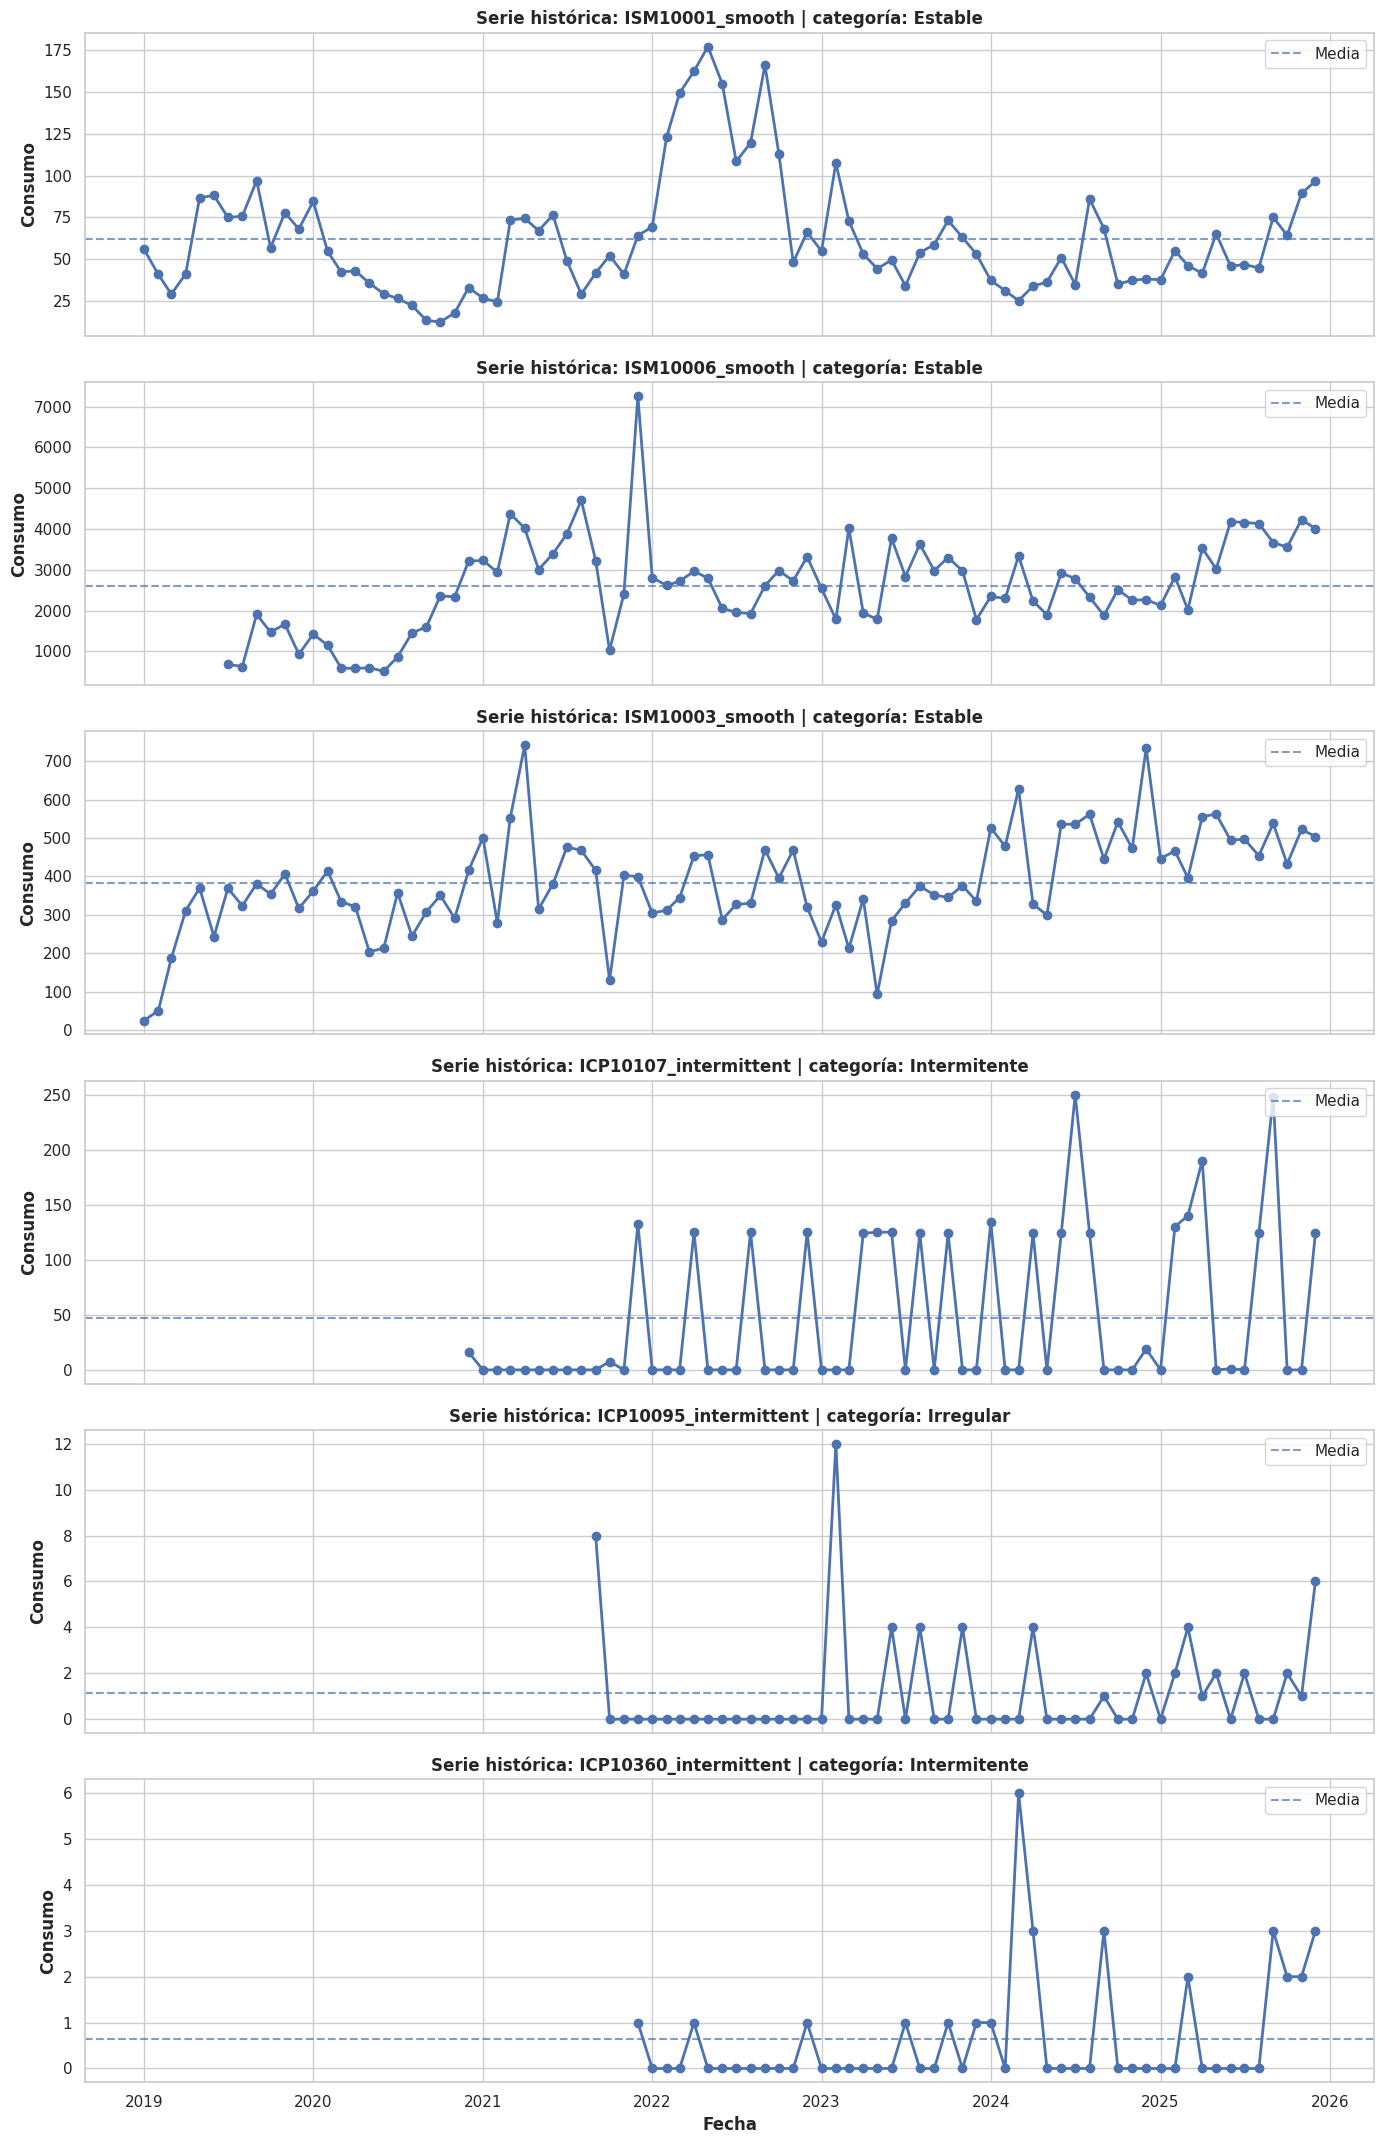

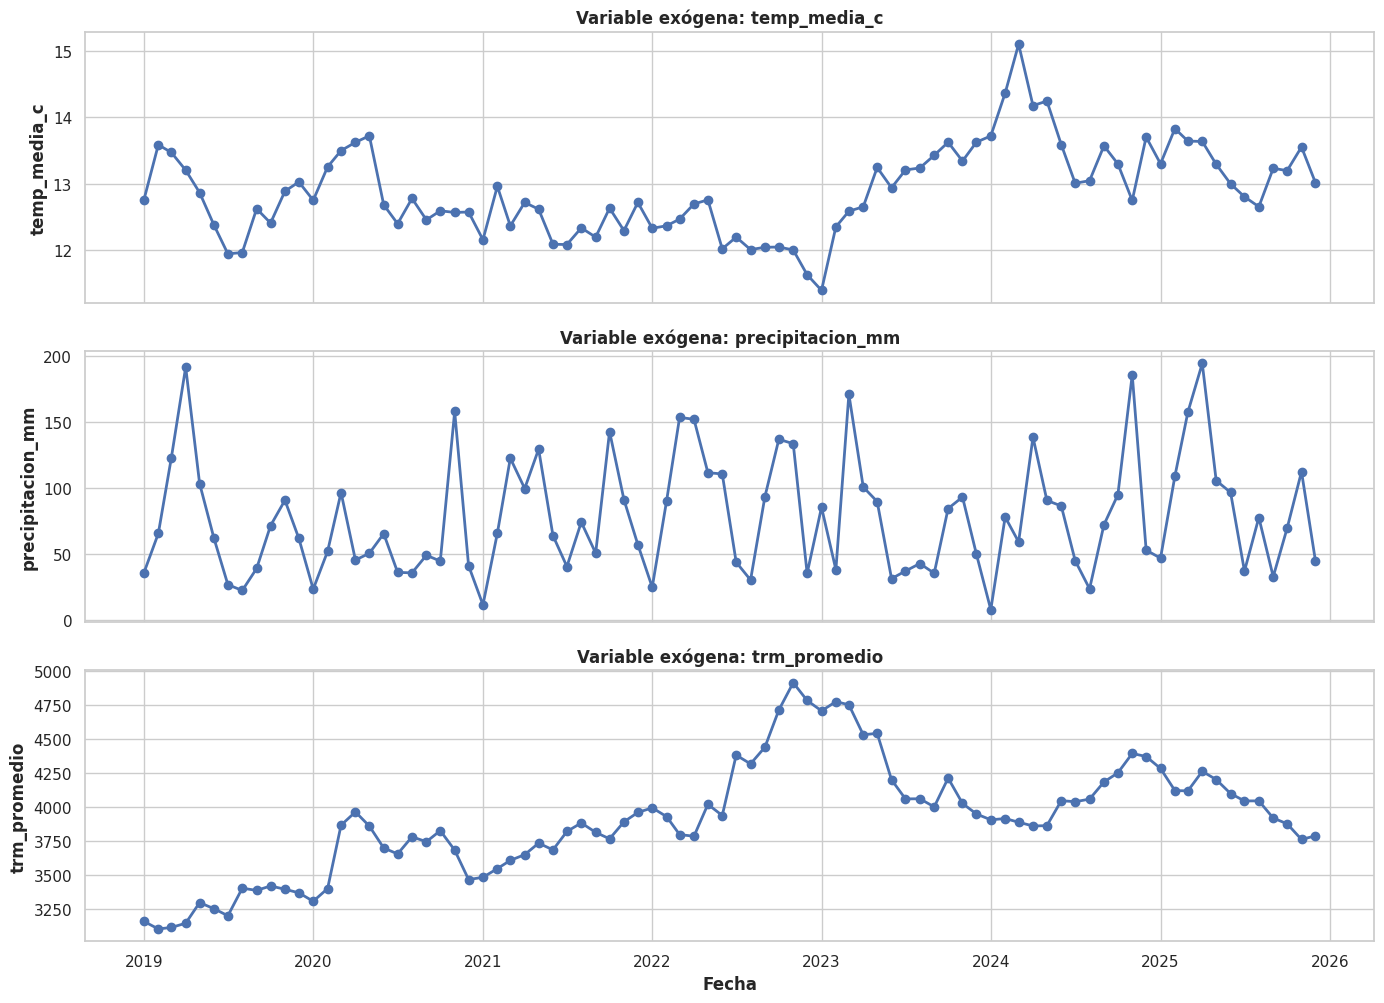

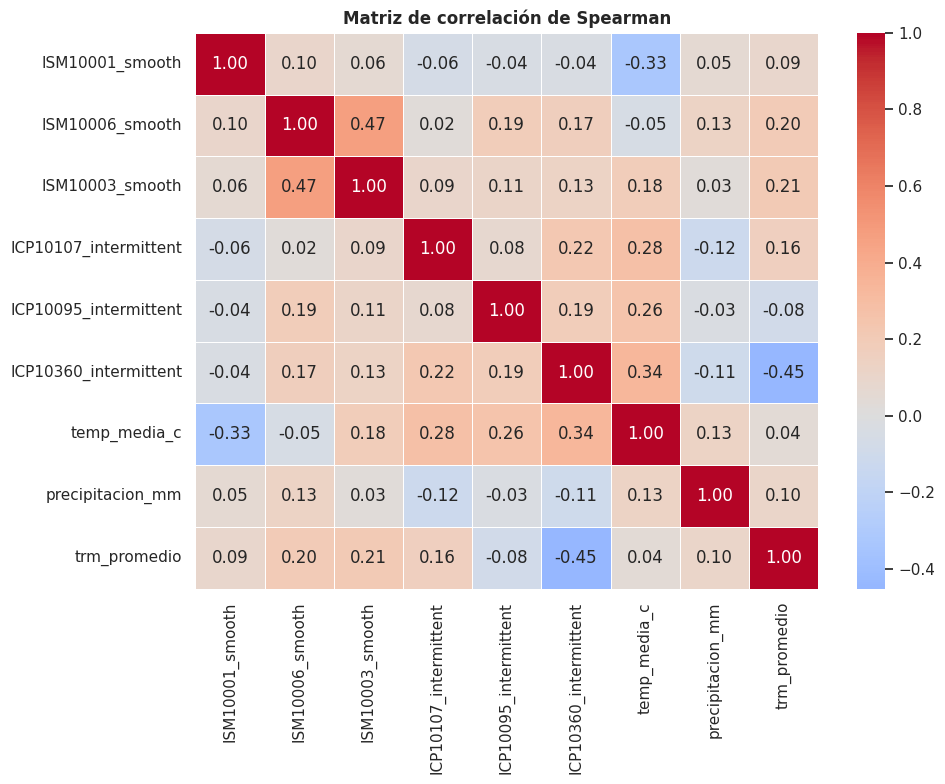

,serie,categoria,n_obs,seasonal_strength,adf_pvalue,kpss_pvalue,acf_lag12,d_sugerido,D_sugerido
0,ISM10001_smooth,Estable,84,0.242,0.0391,0.1000,-0.061,0,0
1,ISM10006_smooth,Estable,78,0.082,0.2228,0.0339,-0.075,1,0
2,ISM10003_smooth,Estable,84,0.000,0.2883,0.0100,0.032,1,0
3,ICP10107_intermittent,Intermitente,61,0.000,0.0000,0.0155,0.069,1,0
4,ICP10095_intermittent,Irregular,52,0.000,0.0000,0.1000,-0.124,0,0
5,ICP10360_intermittent,Intermitente,49,0.228,0.0000,0.0963,0.104,0,0


,variable,VIF
0,temp_media_c,1.020
1,precipitacion_mm,1.036
2,trm_promedio,1.034


,serie,exogena,lag,spearman,abs_corr
0,ICP10095_intermittent,temp_media_c,1,0.285,0.285
1,ICP10107_intermittent,temp_media_c,0,0.276,0.276
2,ICP10360_intermittent,trm_promedio,0,-0.452,0.452
3,ISM10001_smooth,temp_media_c,1,-0.349,0.349
4,ISM10003_smooth,temp_media_c,2,0.289,0.289
5,ISM10006_smooth,trm_promedio,3,0.256,0.256


Bloque tabular y gráfico global ejecutado correctamente.


In [ ]:
# ============================================================
# SECCIÓN 2 | Diagnóstico tabular y gráficos globales
# ============================================================
import warnings
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from IPython.display import display
from statsmodels.tsa.seasonal import STL
from statsmodels.tsa.stattools import adfuller, kpss, acf
from statsmodels.stats.outliers_influence import variance_inflation_factor
import statsmodels.api as sm

warnings.filterwarnings("ignore")

# ------------------------------------------------------------
# Validación de objetos previos
# ------------------------------------------------------------
required_globals = ["df", "DATE_COL", "EXOG_COLS", "TARGET_COLS", "SEASONAL_PERIOD", "audit_df"]
missing_globals = [g for g in required_globals if g not in globals()]
if missing_globals:
    raise ValueError(f"Antes de ejecutar esta sección deben existir las variables de la Sección 1: {missing_globals}")

if "active_slice" not in globals():
    def active_slice(data, col):
        first_idx = data[col].first_valid_index()
        if first_idx is None:
            return data.iloc[0:0].copy()
        return data.loc[first_idx:, [DATE_COL, col] + EXOG_COLS].reset_index(drop=True)

# ------------------------------------------------------------
# Funciones auxiliares
# ------------------------------------------------------------
def seasonal_strength(y, period=12):
    y = pd.Series(y).dropna().astype(float)
    if len(y) < 2 * period:
        return np.nan
    try:
        stl = STL(y, period=period, robust=True).fit()
        den = np.var(stl.seasonal + stl.resid)
        if den == 0:
            return np.nan
        return float(max(0, 1 - np.var(stl.resid) / den))
    except Exception:
        return np.nan

def stationarity_summary(y, period=12):
    y = pd.Series(y).dropna().astype(float)

    out = {
        "n_obs": int(len(y)),
        "seasonal_strength": seasonal_strength(y, period=period),
        "adf_pvalue": np.nan,
        "kpss_pvalue": np.nan,
        "acf_lag12": np.nan,
        "d_sugerido": 0,
        "D_sugerido": 0
    }

    if len(y) < max(18, period + 6):
        return out

    try:
        out["adf_pvalue"] = float(adfuller(y, autolag="AIC")[1])
    except Exception:
        pass

    try:
        out["kpss_pvalue"] = float(kpss(y, regression="c", nlags="auto")[1])
    except Exception:
        pass

    try:
        if len(y) > period:
            out["acf_lag12"] = float(acf(y, nlags=period, fft=False)[period])
    except Exception:
        pass

    adf_non_stationary = pd.notna(out["adf_pvalue"]) and out["adf_pvalue"] >= 0.05
    kpss_non_stationary = pd.notna(out["kpss_pvalue"]) and out["kpss_pvalue"] < 0.05
    out["d_sugerido"] = int(adf_non_stationary or kpss_non_stationary)

    strong_seasonality = pd.notna(out["seasonal_strength"]) and out["seasonal_strength"] >= 0.25
    seasonal_acf = pd.notna(out["acf_lag12"]) and abs(out["acf_lag12"]) >= 0.25
    out["D_sugerido"] = int(strong_seasonality and seasonal_acf and len(y) >= 2 * period)

    return out

def lagged_exog_correlations(data, target_col, exog_cols, max_lag=3):
    active = active_slice(data, target_col).copy()
    rows = []

    for exog in exog_cols:
        for lag in range(max_lag + 1):
            corr = active[target_col].corr(active[exog].shift(lag), method="spearman")
            rows.append({
                "serie": target_col,
                "exogena": exog,
                "lag": lag,
                "spearman": corr,
                "abs_corr": abs(corr) if pd.notna(corr) else np.nan
            })

    return pd.DataFrame(rows)

def style_table(styler, caption):
    return (
        styler
        .set_caption(caption)
        .set_table_styles([
            {"selector": "caption", "props": [("font-size", "14px"), ("font-weight", "bold")]},
            {"selector": "th", "props": [("background-color", "#16324f"), ("color", "white"), ("text-align", "center")]},
            {"selector": "td", "props": [("text-align", "center")]},
        ])
    )

# ------------------------------------------------------------
# 1. Gráficos globales de series y exógenas
# ------------------------------------------------------------
n_targets = len(TARGET_COLS)
fig, axes = plt.subplots(n_targets, 1, figsize=(14, 3.6 * n_targets), sharex=True)
if n_targets == 1:
    axes = [axes]

for ax, target in zip(axes, TARGET_COLS):
    active = active_slice(df, target).copy()
    categoria = audit_df.loc[audit_df["serie"] == target, "categoria_ADI_CV2"].iloc[0]
    ax.plot(active[DATE_COL], active[target], marker="o", linewidth=2)
    ax.axhline(active[target].mean(), linestyle="--", alpha=0.7, label="Media")
    ax.set_title(f"Serie histórica: {target} | categoría: {categoria}")
    ax.set_ylabel("Consumo")
    ax.legend(loc="upper right")

plt.xlabel("Fecha")
plt.tight_layout()
plt.show()

fig, axes = plt.subplots(len(EXOG_COLS), 1, figsize=(14, 3.4 * len(EXOG_COLS)), sharex=True)
if len(EXOG_COLS) == 1:
    axes = [axes]

for ax, exog in zip(axes, EXOG_COLS):
    ax.plot(df[DATE_COL], df[exog], marker="o", linewidth=2)
    ax.set_title(f"Variable exógena: {exog}")
    ax.set_ylabel(exog)

plt.xlabel("Fecha")
plt.tight_layout()
plt.show()

# ------------------------------------------------------------
# 2. Correlación contemporánea global
# ------------------------------------------------------------
corr_df = df[TARGET_COLS + EXOG_COLS].corr(method="spearman")

plt.figure(figsize=(10, 8))
sns.heatmap(corr_df, annot=True, fmt=".2f", cmap="coolwarm", center=0, linewidths=0.5)
plt.title("Matriz de correlación de Spearman")
plt.tight_layout()
plt.show()

# ------------------------------------------------------------
# 3. Diagnóstico tabular por serie
# ------------------------------------------------------------
diag_rows = []
lag_corr_rows = []

for target in TARGET_COLS:
    active = active_slice(df, target)
    y = active[target].astype(float)

    row = {
        "serie": target,
        "categoria": audit_df.loc[audit_df["serie"] == target, "categoria_ADI_CV2"].iloc[0],
    }
    row.update(stationarity_summary(y, period=SEASONAL_PERIOD))
    diag_rows.append(row)

    lag_corr_rows.append(lagged_exog_correlations(df, target, EXOG_COLS, max_lag=3))

diagnostic_df = pd.DataFrame(diag_rows)
lag_corr_df = pd.concat(lag_corr_rows, ignore_index=True)

display(
    style_table(
        diagnostic_df.style
        .format({
            "seasonal_strength": "{:.3f}",
            "adf_pvalue": "{:.4f}",
            "kpss_pvalue": "{:.4f}",
            "acf_lag12": "{:.3f}",
        })
        .background_gradient(subset=["seasonal_strength", "acf_lag12"], cmap="PuBu")
        .apply(
            lambda s: [
                "background-color: #d9ead3; font-weight: bold;" if v == 1
                else "background-color: #fce5cd;" for v in s
            ],
            subset=["d_sugerido", "D_sugerido"]
        ),
        "Diagnóstico preliminar de estacionariedad y estacionalidad"
    )
)

# ------------------------------------------------------------
# 4. Colinealidad entre exógenas
# ------------------------------------------------------------
X_vif = df[EXOG_COLS].dropna().copy()
X_vif = sm.add_constant(X_vif)

vif_df = pd.DataFrame({
    "variable": X_vif.columns[1:],
    "VIF": [variance_inflation_factor(X_vif.values, i) for i in range(1, X_vif.shape[1])]
})

display(
    style_table(
        vif_df.style
        .format({"VIF": "{:.3f}"})
        .background_gradient(subset=["VIF"], cmap="Reds"),
        "Colinealidad entre variables exógenas"
    )
)

# ------------------------------------------------------------
# 5. Mejor relación serie-exógena en rezagos cortos
# ------------------------------------------------------------
lag_summary = (
    lag_corr_df.sort_values(["serie", "abs_corr"], ascending=[True, False])
    .groupby("serie", as_index=False)
    .first()
)

display(
    style_table(
        lag_summary.style
        .format({"spearman": "{:.3f}", "abs_corr": "{:.3f}"})
        .background_gradient(subset=["abs_corr"], cmap="YlOrRd"),
        "Mayor correlación absoluta por serie frente a exógenas y rezagos cortos"
    )
)

print("Bloque tabular y gráfico global ejecutado correctamente.")

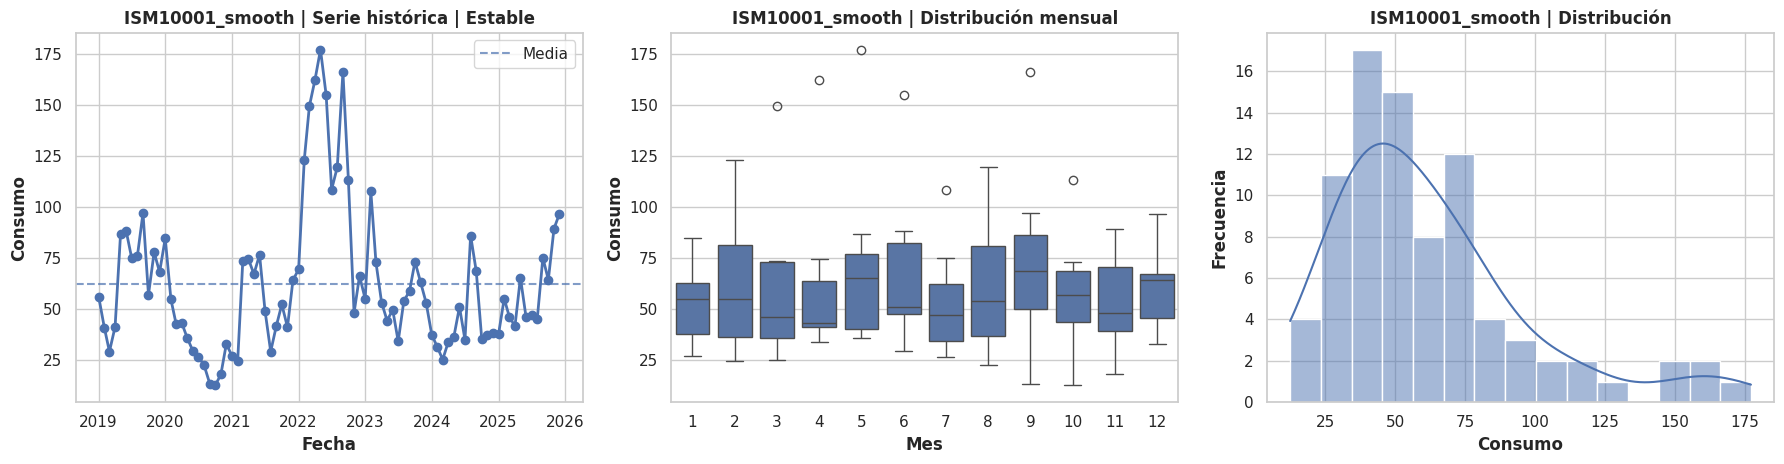

ISM10001_smooth: no fue posible construir el panel STL/ACF/PACF. Motivo: Line2D.set() got an unexpected keyword argument 'method'


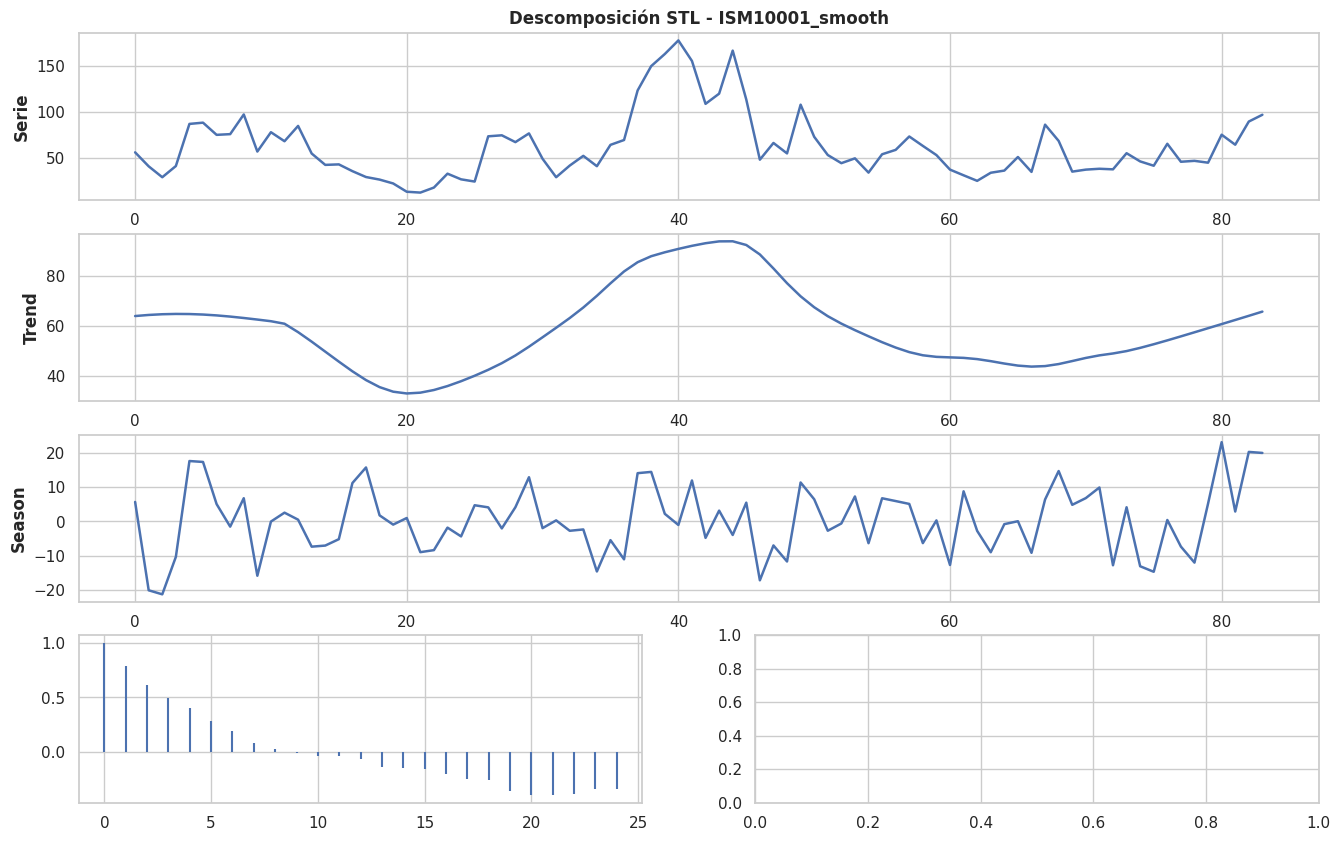

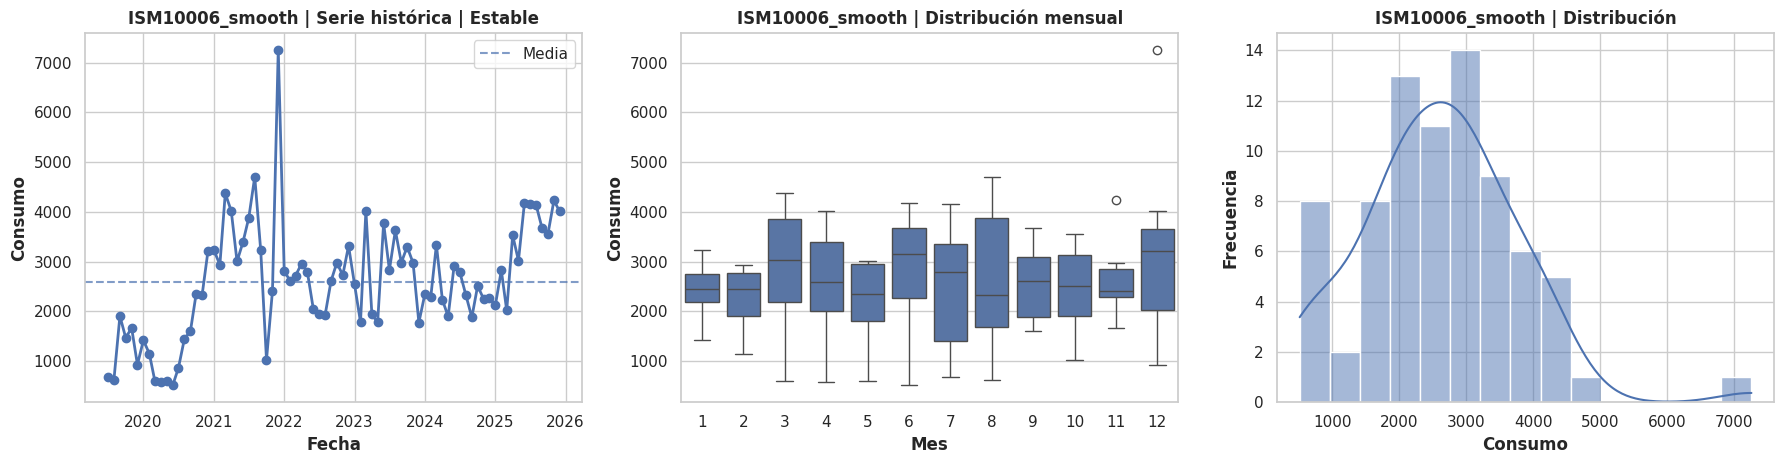

ISM10006_smooth: no fue posible construir el panel STL/ACF/PACF. Motivo: Line2D.set() got an unexpected keyword argument 'method'


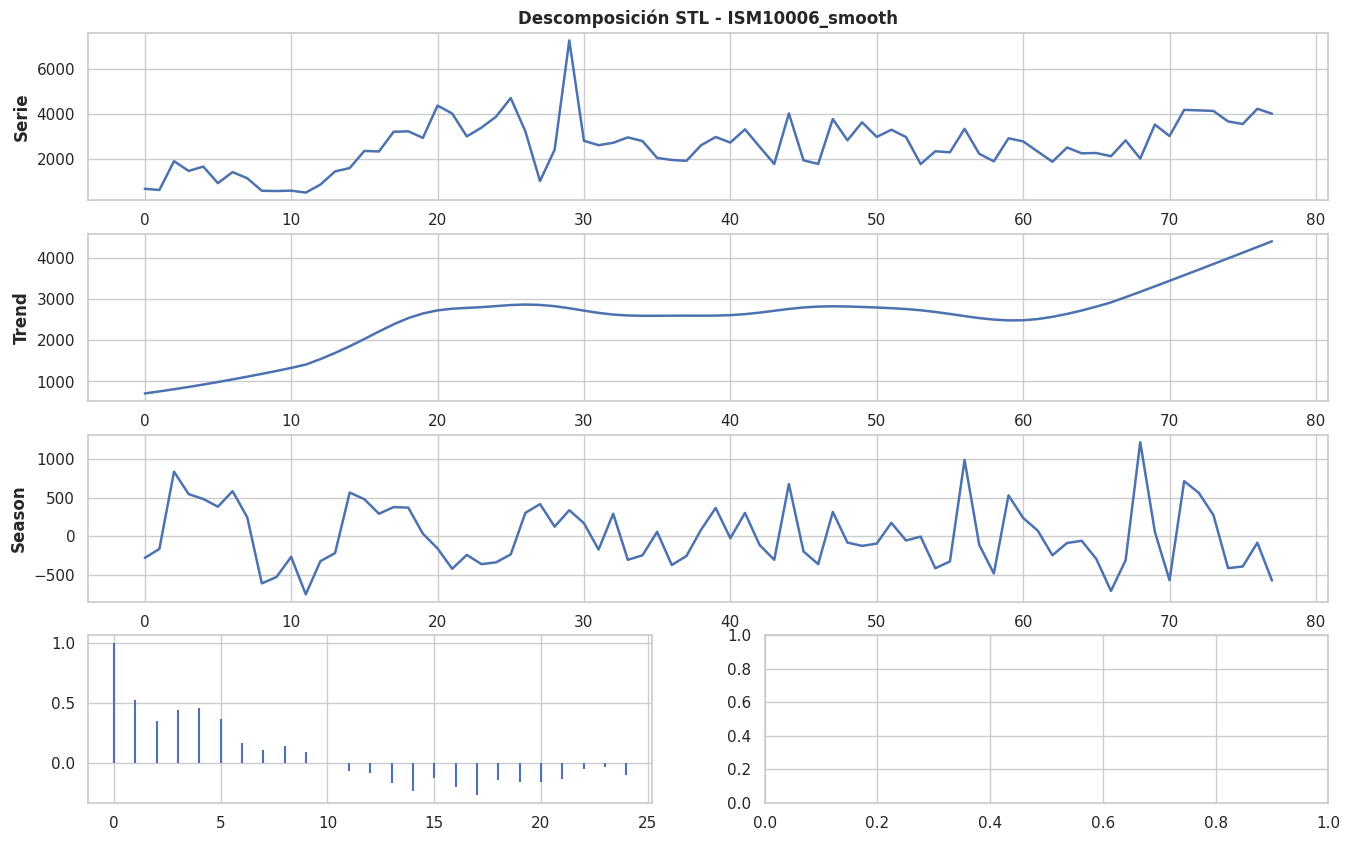

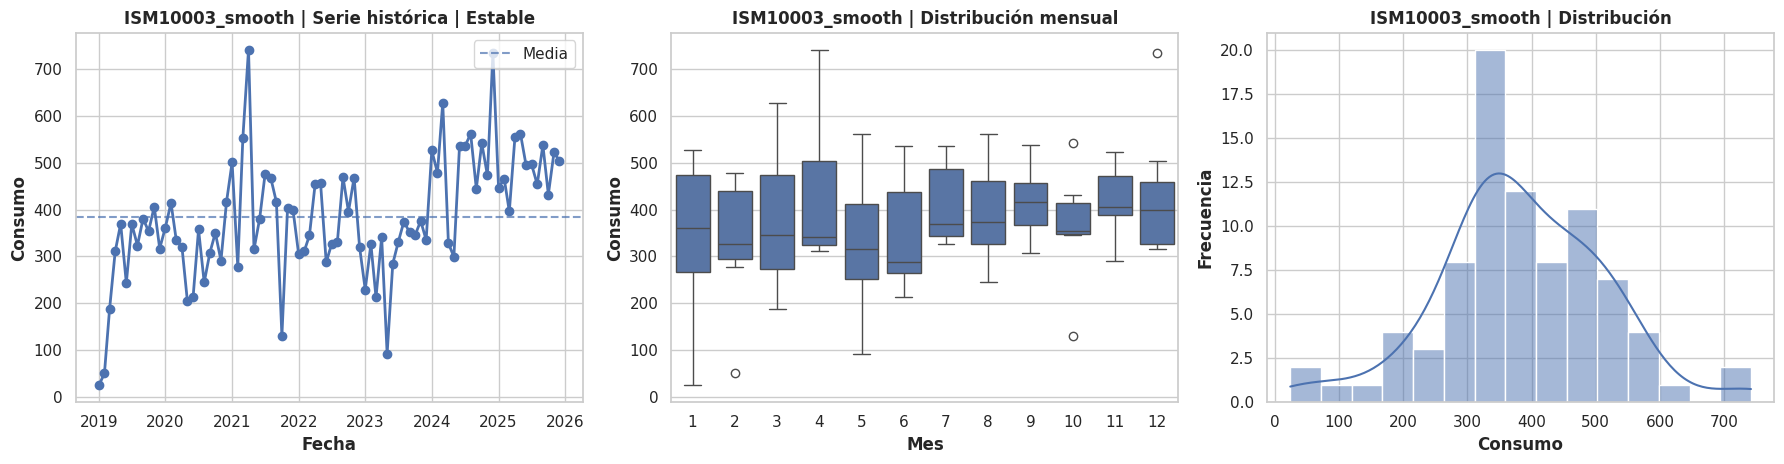

ISM10003_smooth: no fue posible construir el panel STL/ACF/PACF. Motivo: Line2D.set() got an unexpected keyword argument 'method'


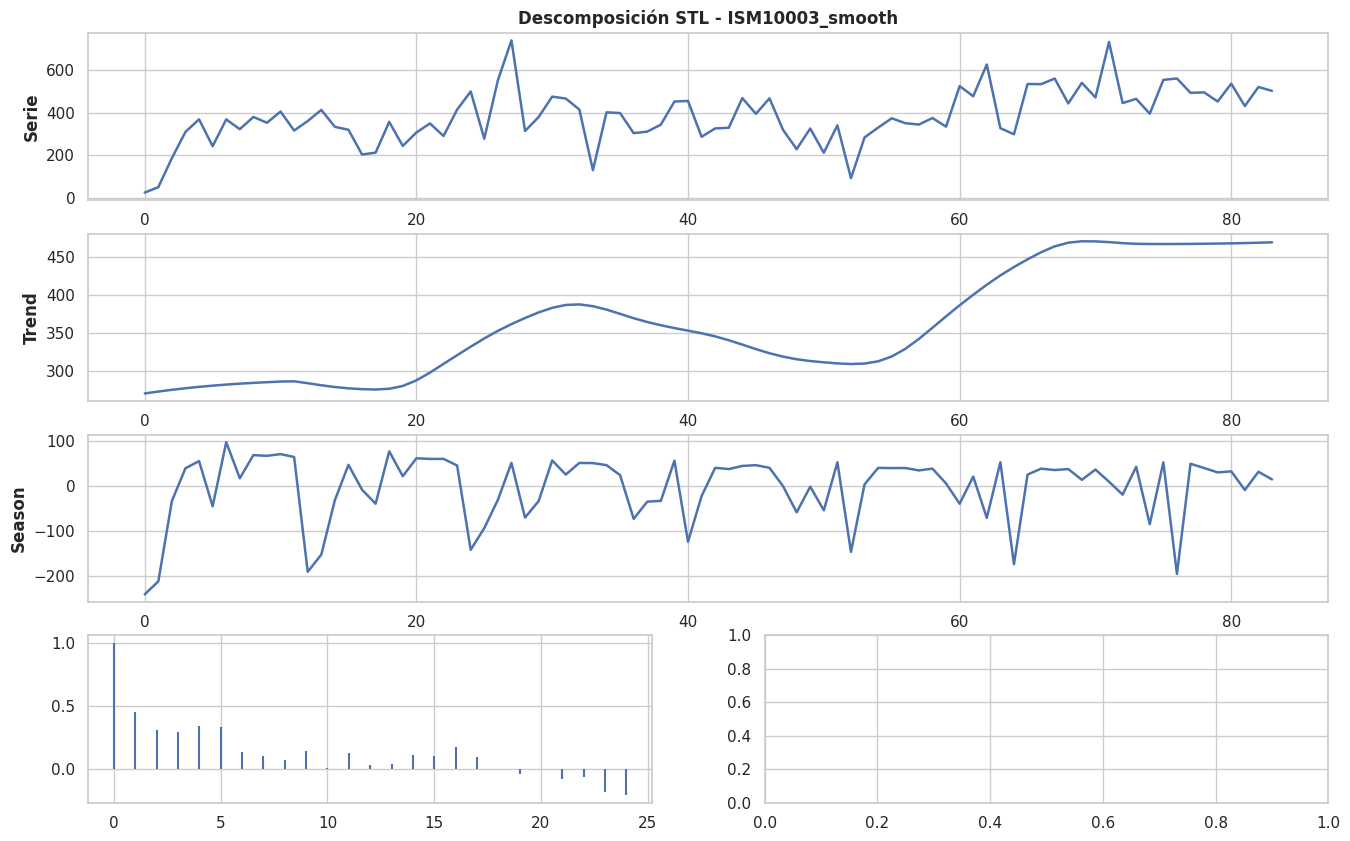

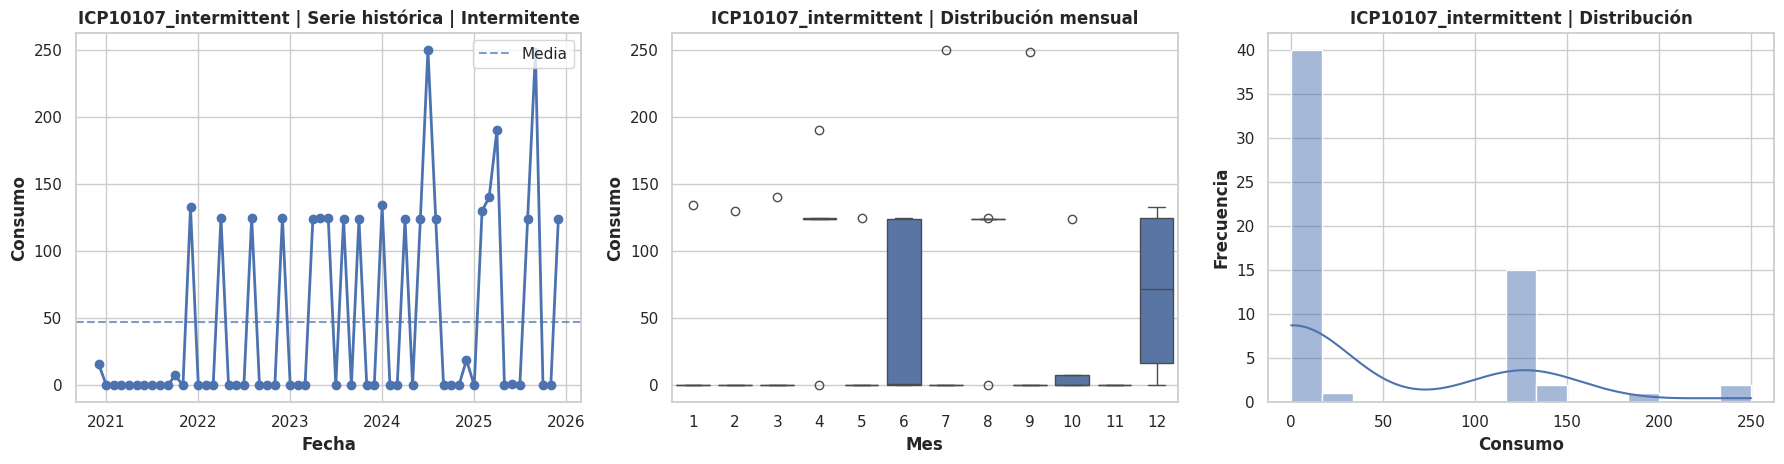

ICP10107_intermittent: no fue posible construir el panel STL/ACF/PACF. Motivo: Line2D.set() got an unexpected keyword argument 'method'


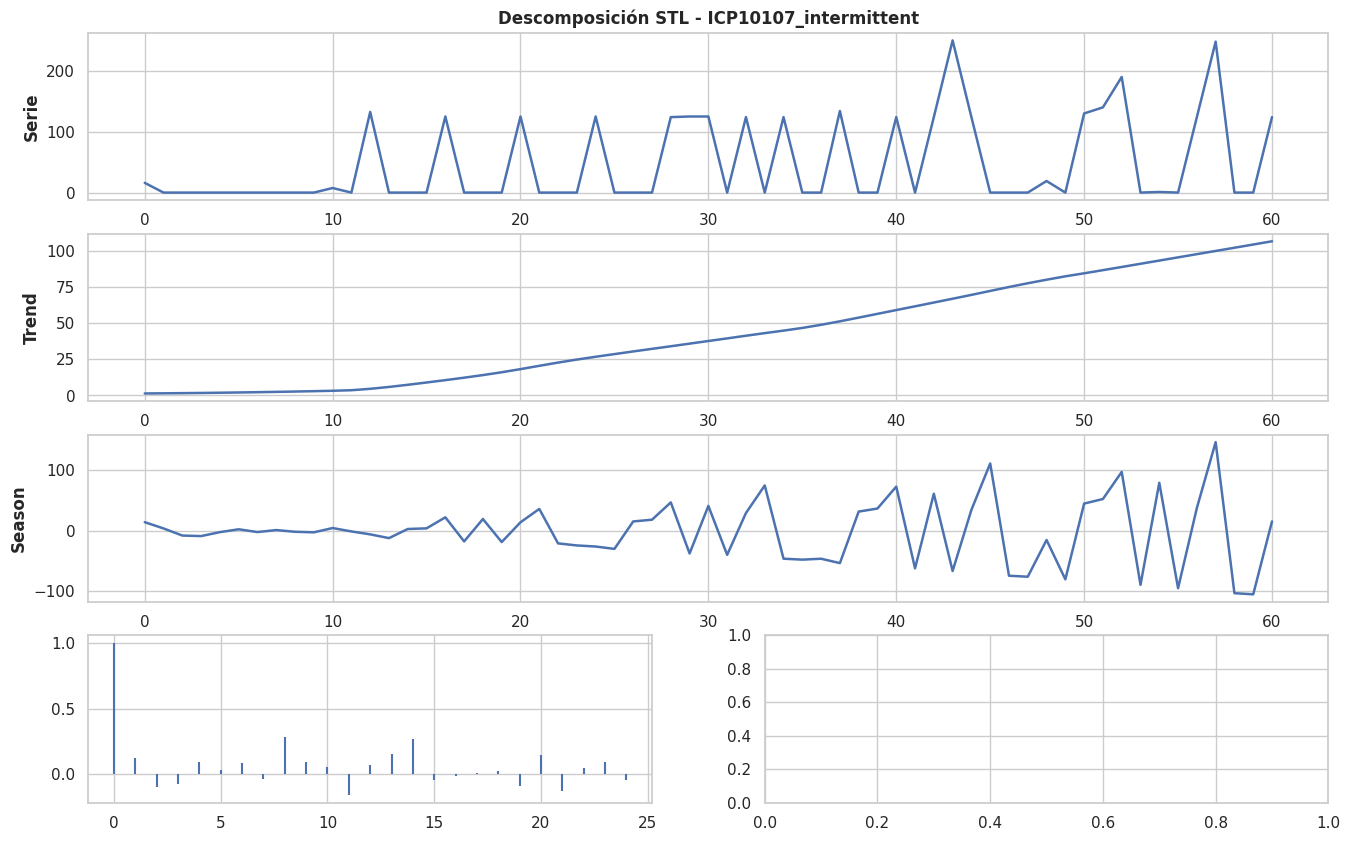

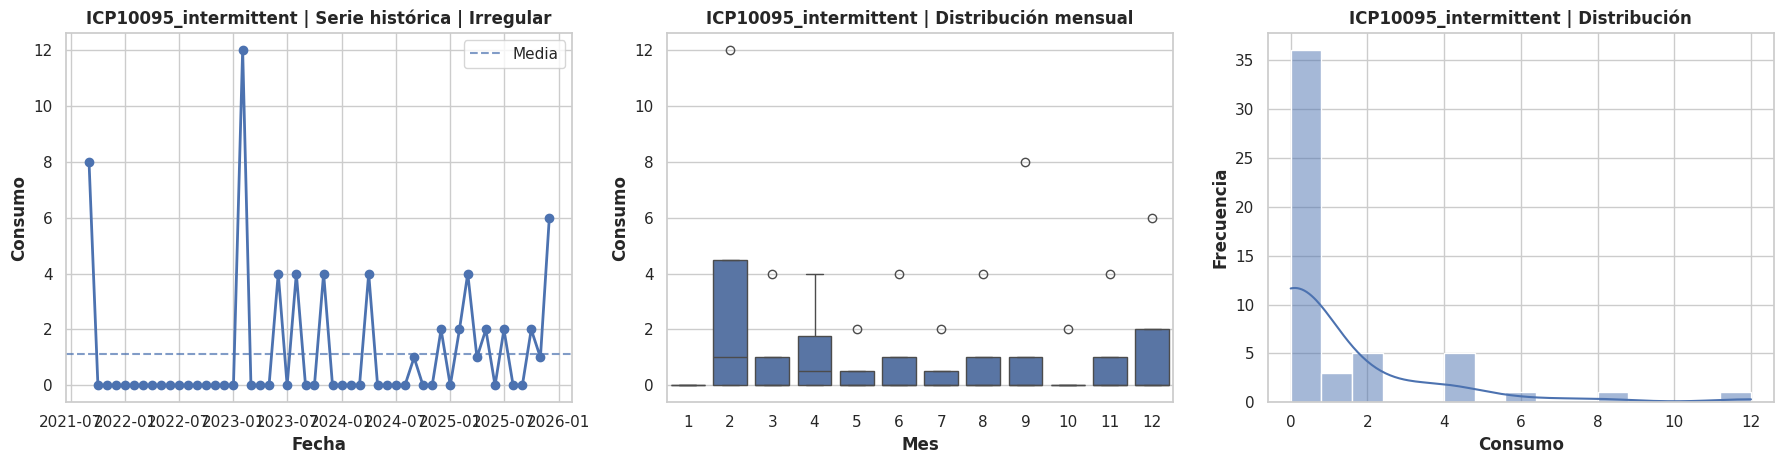

ICP10095_intermittent: no fue posible construir el panel STL/ACF/PACF. Motivo: Line2D.set() got an unexpected keyword argument 'method'


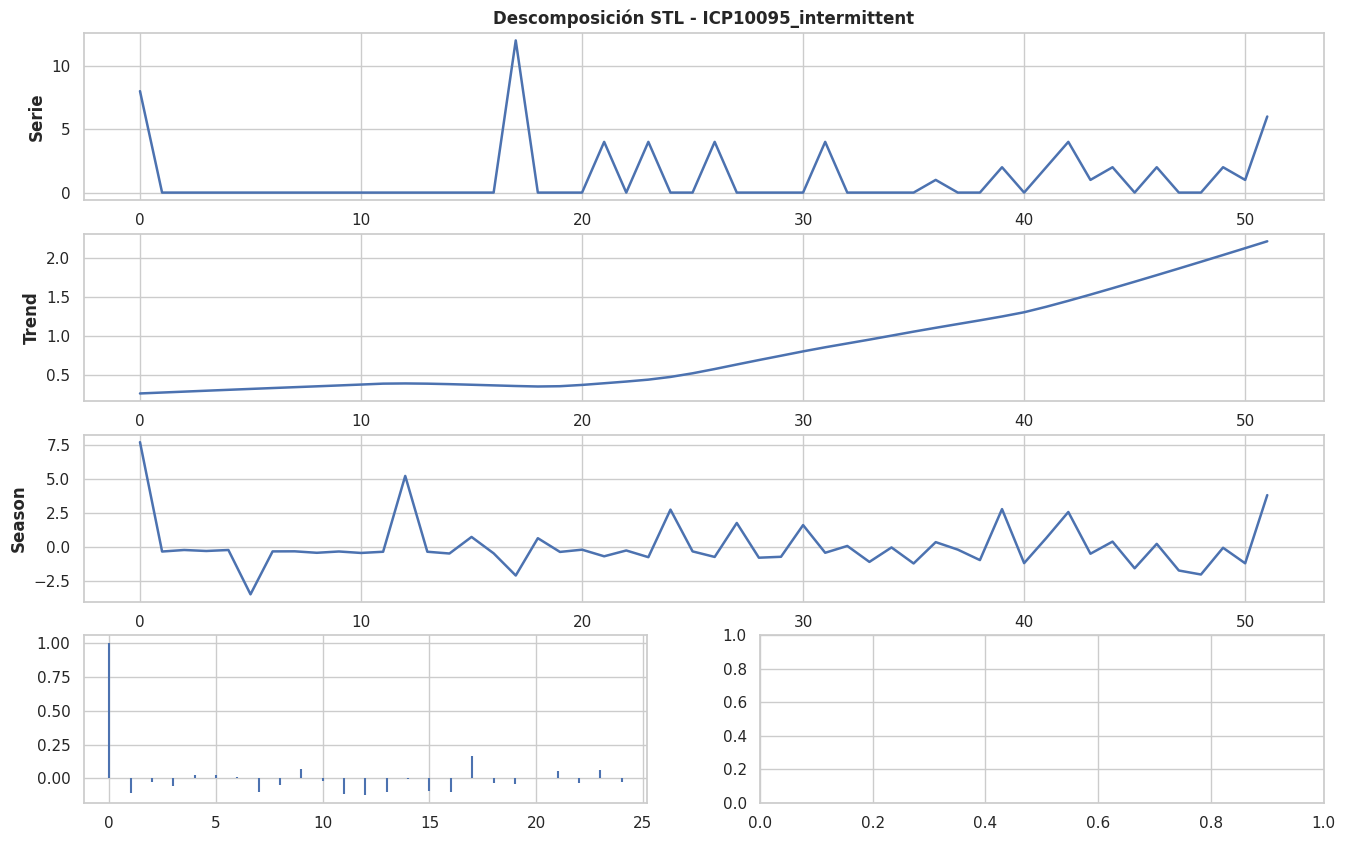

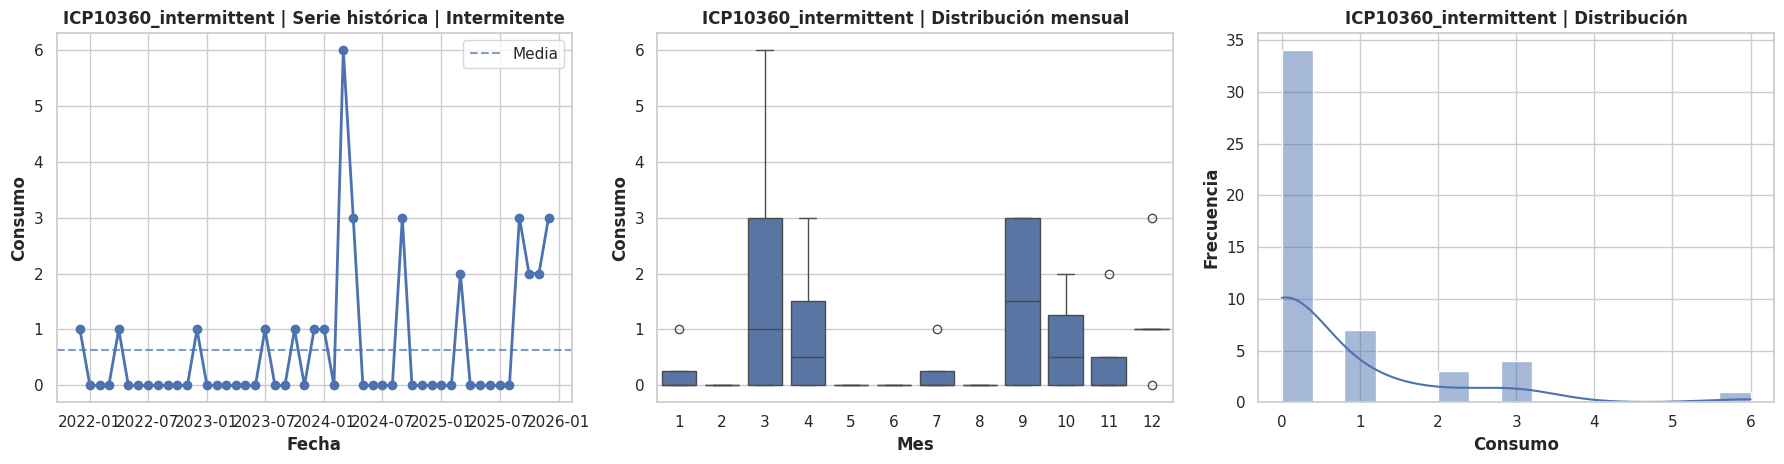

ICP10360_intermittent: no fue posible construir el panel STL/ACF/PACF. Motivo: Line2D.set() got an unexpected keyword argument 'method'
Bloque de paneles por serie ejecutado correctamente.


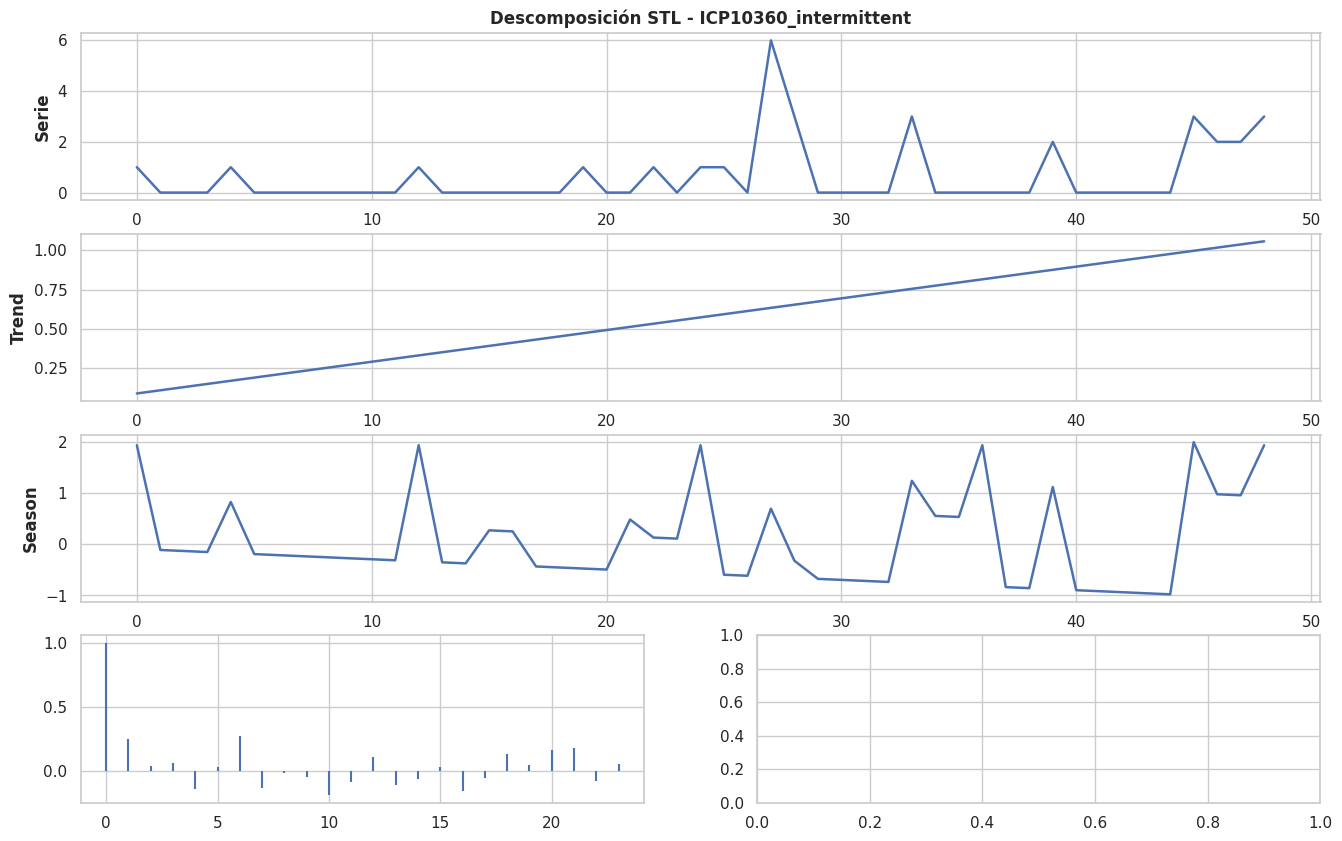

In [ ]:
# ============================================================
# SECCIÓN 2 | Paneles por serie: distribución, STL, ACF y PACF
# ============================================================
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf
from statsmodels.tsa.seasonal import STL

for target in TARGET_COLS:
    active = active_slice(df, target).copy()
    active["mes"] = active[DATE_COL].dt.month
    y = active[target].dropna().astype(float).reset_index(drop=True)

    categoria = audit_df.loc[audit_df["serie"] == target, "categoria_ADI_CV2"].iloc[0]

    # --------------------------------------------------------
    # Panel 1: historia reciente + boxplot mensual + histograma
    # --------------------------------------------------------
    fig, axes = plt.subplots(1, 3, figsize=(18, 4.8))

    axes[0].plot(active[DATE_COL], active[target], marker="o", linewidth=2)
    axes[0].axhline(active[target].mean(), linestyle="--", alpha=0.7, label="Media")
    axes[0].set_title(f"{target} | Serie histórica | {categoria}")
    axes[0].set_xlabel("Fecha")
    axes[0].set_ylabel("Consumo")
    axes[0].legend(loc="upper right")

    sns.boxplot(data=active, x="mes", y=target, ax=axes[1])
    axes[1].set_title(f"{target} | Distribución mensual")
    axes[1].set_xlabel("Mes")
    axes[1].set_ylabel("Consumo")

    sns.histplot(active[target], kde=True, bins=15, ax=axes[2])
    axes[2].set_title(f"{target} | Distribución")
    axes[2].set_xlabel("Consumo")
    axes[2].set_ylabel("Frecuencia")

    plt.tight_layout()
    plt.show()

    # --------------------------------------------------------
    # Panel 2: STL + ACF + PACF
    # --------------------------------------------------------
    if len(y) < 2 * SEASONAL_PERIOD:
        print(f"{target}: longitud insuficiente para descomposición STL con periodo {SEASONAL_PERIOD}.")
        continue

    try:
        stl = STL(y, period=SEASONAL_PERIOD, robust=True).fit()

        fig = plt.figure(figsize=(16, 10))
        gs = fig.add_gridspec(4, 2, height_ratios=[1, 1, 1, 1], width_ratios=[1, 1])

        ax1 = fig.add_subplot(gs[0, :])
        ax2 = fig.add_subplot(gs[1, :])
        ax3 = fig.add_subplot(gs[2, :])
        ax4 = fig.add_subplot(gs[3, 0])
        ax5 = fig.add_subplot(gs[3, 1])

        ax1.plot(y.values, linewidth=1.8)
        ax1.set_title(f"Descomposición STL - {target}")
        ax1.set_ylabel("Serie")

        ax2.plot(stl.trend, linewidth=1.8)
        ax2.set_ylabel("Trend")

        ax3.plot(stl.seasonal, linewidth=1.8)
        ax3.set_ylabel("Season")

        plot_acf(y, lags=min(24, max(1, len(y)//2 - 1)), ax=ax4, method="ywm")
        ax4.set_title(f"ACF - {target}")

        plot_pacf(y, lags=min(24, max(1, len(y)//2 - 1)), ax=ax5, method="ywm")
        ax5.set_title(f"PACF - {target}")

        plt.tight_layout()
        plt.show()

    except Exception as e:
        print(f"{target}: no fue posible construir el panel STL/ACF/PACF. Motivo: {e}")

print("Bloque de paneles por serie ejecutado correctamente.")

# **3. Backtesting rolling-origin y comparación de modelos por familia de demanda**

> **Propósito técnico.**  
> Esta sección implementa la validación fuera de muestra del sistema de pronóstico. La comparación se realiza con un esquema **rolling-origin de un paso adelante**, manteniendo separadas las familias de series para evitar contrastes metodológicamente inconsistentes entre demanda continua y demanda intermitente.

---

## 3.1. Esquema de validación temporal

Para cada serie se toma el tramo final del histórico como ventana de prueba. En cada origen de validación, el modelo se reentrena con información disponible hasta el periodo $\tau$ y pronostica el siguiente mes:

$$
\hat{y}_{\tau+1 \mid \tau} = f\!\left(y_{1:\tau},\ X_{1:\tau},\ X_{\tau+1}\right)
$$

El procedimiento se repite de manera secuencial sobre los últimos $H$ periodos, preservando la causalidad temporal y evitando mezclar información futura dentro del entrenamiento.

---

## 3.2. Familias comparadas

### Series smooth

| Modelo | Naturaleza | Papel dentro de la comparación |
|---|---|---|
| **Seasonal Naive** | base estacional | línea base mínima para contrastar ganancia real |
| **ETS amortiguado** | suavizamiento exponencial | benchmark de series continuas sin exógenas |
| **SARIMAX exógeno** | econométrico-condicional | modelo principal para series smooth con exógenas |

### Series intermitentes

| Modelo | Naturaleza | Papel dentro de la comparación |
|---|---|---|
| **Croston-SBA** | clásico para demanda esporádica | referencia analítica especializada |
| **TSB** | intermitente con actualización de probabilidad | benchmark robusto frente a muchos ceros |
| **Hurdle-RF dinámico** | dos etapas: ocurrencia y magnitud | alternativa flexible con exógenas y rezagos |

---

## 3.3. Parametrización del bloque SARIMAX

Para mantener el backtesting computacionalmente manejable, la estructura del SARIMAX no se reoptimiza desde cero en cada partición. En su lugar, la especificación se construye a partir del diagnóstico de la sección anterior:

- $d$ se toma de la sugerencia de diferenciación en nivel;
- $D$ se toma de la sugerencia de diferenciación estacional;
- la estructura autoregresiva y de medias móviles se fija en una forma parsimoniosa pero suficientemente flexible para capturar oscilaciones y cambios de nivel.

La forma general evaluada es:

$$
\Phi_P(B^{12})\,\phi_p(B)\,(1-B)^d\,(1-B^{12})^D\,y_t
=
\beta^\top X_t + \Theta_Q(B^{12})\,\theta_q(B)\,\varepsilon_t
$$

donde $X_t$ contiene temperatura media, precipitación y TRM.

---

## 3.4. Métricas de evaluación

Las métricas se calculan sobre los pronósticos fuera de muestra generados por el rolling-origin:

$$
MAE = \frac{1}{n}\sum_{t=1}^{n}\left|y_t-\hat{y}_t\right|
$$

$$
RMSE = \sqrt{\frac{1}{n}\sum_{t=1}^{n}\left(y_t-\hat{y}_t\right)^2}
$$

$$
sMAPE = \frac{100}{n}\sum_{t=1}^{n}
\frac{2\left|y_t-\hat{y}_t\right|}{\left|y_t\right|+\left|\hat{y}_t\right|}
$$

$$
WAPE = 100\cdot \frac{\sum_{t=1}^{n}\left|y_t-\hat{y}_t\right|}{\sum_{t=1}^{n}\left|y_t\right|}
$$

$$
MASE = \frac{\frac{1}{n}\sum_{t=1}^{n}\left|y_t-\hat{y}_t\right|}
{\frac{1}{T-m}\sum_{t=m+1}^{T}\left|y_t-y_{t-m}\right|}
$$

Además, se conserva una métrica operativa adicional:

| Métrica | Interpretación |
|---|---|
| **Bias %** | sesgo agregado del pronóstico frente al total observado |
| **Activity Acc** | proporción de aciertos entre meses con consumo positivo y meses con consumo cero |

---

## 3.5. Regla de selección

La elección del mejor modelo por serie se apoya en un ranking compuesto por:

1. **WAPE**  
2. **RMSE**  
3. **MAE**

El mejor modelo será el que presente la menor posición promedio en esas tres métricas, priorizando error absoluto relativo y estabilidad de ajuste fuera de muestra.

---

> **Nota metodológica.**  
> El objetivo de esta sección no consiste todavía en generar el pronóstico final a 12 meses, sino en establecer, con evidencia cuantitativa y comparable, qué arquitectura conviene conservar para cada SKU antes de estimar el modelo definitivo.

In [ ]:
# ============================================================
# SECCIÓN 3 | Funciones de backtesting y familias de modelos
# ============================================================
import warnings
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from IPython.display import display
from statsmodels.tsa.statespace.sarimax import SARIMAX
from statsmodels.tsa.holtwinters import ExponentialSmoothing
from sklearn.ensemble import RandomForestClassifier, RandomForestRegressor

warnings.filterwarnings("ignore")

# ------------------------------------------------------------
# Validación mínima de objetos previos
# ------------------------------------------------------------
required_globals = ["df", "DATE_COL", "EXOG_COLS", "TARGET_COLS", "SEASONAL_PERIOD", "audit_df"]
missing_globals = [g for g in required_globals if g not in globals()]
if missing_globals:
    raise ValueError(f"Antes de ejecutar esta sección deben existir las variables previas: {missing_globals}")

if "SMOOTH_COLS" not in globals():
    SMOOTH_COLS = [c for c in TARGET_COLS if c.endswith("_smooth")]

if "SPARSE_COLS" not in globals():
    SPARSE_COLS = [c for c in TARGET_COLS if c.endswith("_intermittent")]

if "active_slice" not in globals():
    def active_slice(data, col):
        first_idx = data[col].first_valid_index()
        if first_idx is None:
            return data.iloc[0:0].copy()
        return data.loc[first_idx:, [DATE_COL, col] + EXOG_COLS].reset_index(drop=True)

# ------------------------------------------------------------
# Estilo de tablas
# ------------------------------------------------------------
def style_table(styler, caption):
    return (
        styler
        .set_caption(caption)
        .set_table_styles([
            {"selector": "caption", "props": [("font-size", "14px"), ("font-weight", "bold")]},
            {"selector": "th", "props": [("background-color", "#16324f"), ("color", "white"), ("text-align", "center")]},
            {"selector": "td", "props": [("text-align", "center")]},
        ])
    )

# ------------------------------------------------------------
# Modelos baseline smooth
# ------------------------------------------------------------
def forecast_seasonal_naive(y_train, h=1, m=12):
    y = pd.Series(y_train).dropna().astype(float)
    if len(y) == 0:
        return np.zeros(h)
    if len(y) >= m:
        fc = np.repeat(float(y.iloc[-m]), h)
    else:
        fc = np.repeat(float(y.iloc[-1]), h)
    return np.maximum(fc, 0)

def forecast_ets(y_train, h=1, m=12):
    y = pd.Series(y_train).dropna().astype(float)
    if len(y) < max(8, m):
        return forecast_seasonal_naive(y, h=h, m=m)

    try:
        if len(y) >= 2 * m:
            fit = ExponentialSmoothing(
                y,
                trend="add",
                damped_trend=True,
                seasonal="add",
                seasonal_periods=m,
                initialization_method="estimated",
            ).fit(optimized=True, use_brute=True)
        else:
            fit = ExponentialSmoothing(
                y,
                trend="add",
                damped_trend=True,
                seasonal=None,
                initialization_method="estimated",
            ).fit(optimized=True, use_brute=True)

        fc = fit.forecast(h)
        return np.maximum(np.asarray(fc, dtype=float), 0)
    except Exception:
        return forecast_seasonal_naive(y, h=h, m=m)

# ------------------------------------------------------------
# SARIMAX exógeno parsimonioso guiado por diagnóstico
# ------------------------------------------------------------
def infer_sarimax_spec(series_name):
    d = 1
    D = 1
    seasonal_strength = np.nan

    if "diagnostic_df" in globals():
        row = diagnostic_df.loc[diagnostic_df["serie"] == series_name]
        if not row.empty:
            d = int(row["d_sugerido"].iloc[0])
            D = int(row["D_sugerido"].iloc[0])
            seasonal_strength = row["seasonal_strength"].iloc[0]

    if pd.isna(seasonal_strength):
        seasonal_strength = 0.0

    # Estructura parsimoniosa pero flexible
    order = (2, d, 1) if seasonal_strength >= 0.25 else (1, d, 1)
    seasonal_order = (1, D, 1, SEASONAL_PERIOD) if D == 1 else (0, 0, 0, SEASONAL_PERIOD)

    return {
        "order": order,
        "seasonal_order": seasonal_order,
        "trend": "c"
    }

def forecast_sarimax_exog(y_train, X_train, X_future, spec, h=1):
    y = pd.Series(y_train).dropna().astype(float)
    Xtr = pd.DataFrame(X_train).astype(float)
    Xfu = pd.DataFrame(X_future).astype(float)

    if len(y) < max(18, SEASONAL_PERIOD + 6):
        return forecast_ets(y, h=h, m=SEASONAL_PERIOD)

    try:
        model = SARIMAX(
            y,
            exog=Xtr,
            order=spec["order"],
            seasonal_order=spec["seasonal_order"],
            trend=spec["trend"],
            enforce_stationarity=False,
            enforce_invertibility=False,
            simple_differencing=True,
        )
        fit = model.fit(disp=False, maxiter=80)
        fc = fit.get_forecast(steps=h, exog=Xfu).predicted_mean
        return np.maximum(np.asarray(fc, dtype=float), 0)
    except Exception:
        return forecast_ets(y, h=h, m=SEASONAL_PERIOD)

# ------------------------------------------------------------
# Modelos especializados para demanda intermitente
# ------------------------------------------------------------
def croston_sba_forecast(y, h=1, alpha_grid=(0.05, 0.10, 0.20, 0.30)):
    y = np.asarray(pd.Series(y).fillna(0).astype(float))
    if (y > 0).sum() == 0:
        return np.zeros(h)

    best_fc = None
    best_mae = np.inf
    nz = np.where(y > 0)[0]
    first = nz[0]

    for alpha in alpha_grid:
        z = y[first]
        p = 1.0
        interval = 1
        errors = []

        for t in range(first + 1, len(y)):
            fc = (1 - alpha / 2.0) * (z / max(p, 1e-8))
            errors.append(abs(y[t] - fc))

            if y[t] > 0:
                z = z + alpha * (y[t] - z)
                p = p + alpha * (interval - p)
                interval = 1
            else:
                interval += 1

        mae = np.mean(errors) if errors else np.inf
        fc_last = (1 - alpha / 2.0) * (z / max(p, 1e-8))

        if mae < best_mae:
            best_mae = mae
            best_fc = np.repeat(max(fc_last, 0), h)

    return np.asarray(best_fc, dtype=float)

def tsb_forecast(y, h=1, alpha_d_grid=(0.05, 0.10, 0.20, 0.30), alpha_p_grid=(0.05, 0.10, 0.20, 0.30)):
    y = np.asarray(pd.Series(y).fillna(0).astype(float))
    if (y > 0).sum() == 0:
        return np.zeros(h)

    best_fc = None
    best_mae = np.inf
    nz = np.where(y > 0)[0]
    first = nz[0]

    for alpha_d in alpha_d_grid:
        for alpha_p in alpha_p_grid:
            z = y[first]
            p = 1.0
            errors = []

            for t in range(first + 1, len(y)):
                fc = p * z
                errors.append(abs(y[t] - fc))

                if y[t] > 0:
                    z = z + alpha_d * (y[t] - z)
                    p = p + alpha_p * (1.0 - p)
                else:
                    p = p + alpha_p * (0.0 - p)

            mae = np.mean(errors) if errors else np.inf
            fc_last = p * z

            if mae < best_mae:
                best_mae = mae
                best_fc = np.repeat(max(fc_last, 0), h)

    return np.asarray(best_fc, dtype=float)

def build_hurdle_training_frame(active_df, target):
    work = active_df[[DATE_COL, target] + EXOG_COLS].copy()
    y = work[target].astype(float)

    work["month"] = work[DATE_COL].dt.month.astype(int)
    work["trend"] = np.arange(len(work))

    for lag in [1, 2, 3, 6, 12]:
        work[f"lag_{lag}"] = y.shift(lag)

    work["roll_mean_3"] = y.shift(1).rolling(3).mean()
    work["roll_mean_6"] = y.shift(1).rolling(6).mean()
    work["roll_nz_6"] = (y.shift(1) > 0).rolling(6).mean()
    work["target"] = y

    feature_cols = EXOG_COLS + [
        "month", "trend",
        "lag_1", "lag_2", "lag_3", "lag_6", "lag_12",
        "roll_mean_3", "roll_mean_6", "roll_nz_6"
    ]

    model_df = work.dropna(subset=feature_cols + ["target"]).reset_index(drop=True)
    return model_df, feature_cols

def make_hurdle_future_row(train_active_df, target, future_date, future_exog):
    y = train_active_df[target].astype(float).reset_index(drop=True)

    row = {k: float(v) for k, v in future_exog.items()}
    row["month"] = int(pd.Timestamp(future_date).month)
    row["trend"] = int(len(y))

    for lag in [1, 2, 3, 6, 12]:
        row[f"lag_{lag}"] = float(y.iloc[-lag]) if len(y) >= lag else np.nan

    row["roll_mean_3"] = float(y.iloc[-3:].mean()) if len(y) >= 3 else np.nan
    row["roll_mean_6"] = float(y.iloc[-6:].mean()) if len(y) >= 6 else np.nan
    row["roll_nz_6"] = float((y.iloc[-6:] > 0).mean()) if len(y) >= 6 else np.nan

    return pd.DataFrame([row])

def hurdle_rf_forecast(train_active_df, target, future_date, future_exog):
    model_df, feature_cols = build_hurdle_training_frame(train_active_df, target)
    x_future = make_hurdle_future_row(train_active_df, target, future_date, future_exog)

    if model_df.empty or x_future[feature_cols].isna().any().any():
        return float(tsb_forecast(train_active_df[target], h=1)[0])

    X = model_df[feature_cols]
    y = model_df["target"].astype(float)
    y_bin = (y > 0).astype(int)

    if len(X) < 15 or y_bin.nunique() < 2 or y_bin.sum() < 4:
        return float(tsb_forecast(train_active_df[target], h=1)[0])

    clf = RandomForestClassifier(
        n_estimators=250,
        max_depth=5,
        min_samples_leaf=2,
        class_weight="balanced_subsample",
        random_state=globals().get("RANDOM_STATE", 42),
    )
    clf.fit(X, y_bin)

    reg = RandomForestRegressor(
        n_estimators=250,
        max_depth=5,
        min_samples_leaf=2,
        random_state=globals().get("RANDOM_STATE", 42),
    )
    reg.fit(X.loc[y > 0], y.loc[y > 0])

    prob = clf.predict_proba(x_future[feature_cols])[0, 1]
    threshold = float(np.clip(y_bin.mean(), 0.35, 0.60))
    active_pred = int(prob >= threshold)
    amount_pred = float(max(reg.predict(x_future[feature_cols])[0], 0))

    return float(active_pred * amount_pred)

# ------------------------------------------------------------
# Métricas
# ------------------------------------------------------------
def smape(y_true, y_pred):
    y_true = np.asarray(y_true, dtype=float)
    y_pred = np.asarray(y_pred, dtype=float)
    denom = np.abs(y_true) + np.abs(y_pred)
    return float(np.mean(np.where(denom > 1e-8, 2 * np.abs(y_true - y_pred) / denom, 0.0)) * 100)

def wape(y_true, y_pred):
    y_true = np.asarray(y_true, dtype=float)
    y_pred = np.asarray(y_pred, dtype=float)
    denom = np.abs(y_true).sum()
    if denom <= 1e-8:
        return np.nan
    return float(np.abs(y_true - y_pred).sum() / denom * 100)

def mase(y_true, y_pred, insample, m=1):
    y_true = np.asarray(y_true, dtype=float)
    y_pred = np.asarray(y_pred, dtype=float)
    insample = np.asarray(insample, dtype=float)

    if len(insample) <= m:
        scale = np.mean(np.abs(np.diff(insample))) if len(insample) > 1 else np.nan
    else:
        scale = np.mean(np.abs(insample[m:] - insample[:-m]))

    if pd.isna(scale) or scale <= 1e-8:
        return np.nan

    return float(np.mean(np.abs(y_true - y_pred)) / scale)

def compute_metrics(pred_df, insample, seasonal_m):
    y_true = pred_df["actual"].to_numpy(dtype=float)
    y_pred = pred_df["pred"].to_numpy(dtype=float)
    err = y_pred - y_true

    return {
        "n_test": int(len(pred_df)),
        "MAE": float(np.mean(np.abs(err))),
        "RMSE": float(np.sqrt(np.mean(err**2))),
        "sMAPE_pct": smape(y_true, y_pred),
        "WAPE_pct": wape(y_true, y_pred),
        "MASE": mase(y_true, y_pred, insample=insample, m=seasonal_m),
        "Bias_pct": float(err.sum() / max(np.abs(y_true).sum(), 1e-8) * 100),
        "Activity_acc": float(np.mean((y_true > 0) == (y_pred > 0))),
    }

# ------------------------------------------------------------
# Backtesting rolling-origin
# ------------------------------------------------------------
SMOOTH_MODELS = ["SeasonalNaive", "ETS", "SARIMAX_EXOG"]
SPARSE_MODELS = ["CrostonSBA", "TSB", "HurdleRF"]

def one_step_forecast(model_name, target, train_y, train_X, future_X, future_date, train_active_df, sarimax_spec=None):
    if model_name == "SeasonalNaive":
        return float(forecast_seasonal_naive(train_y, h=1, m=SEASONAL_PERIOD)[0])

    if model_name == "ETS":
        return float(forecast_ets(train_y, h=1, m=SEASONAL_PERIOD)[0])

    if model_name == "SARIMAX_EXOG":
        return float(forecast_sarimax_exog(train_y, train_X, future_X, spec=sarimax_spec, h=1)[0])

    if model_name == "CrostonSBA":
        return float(croston_sba_forecast(train_y, h=1)[0])

    if model_name == "TSB":
        return float(tsb_forecast(train_y, h=1)[0])

    if model_name == "HurdleRF":
        return float(hurdle_rf_forecast(train_active_df, target, future_date, future_X.iloc[0].to_dict()))

    raise ValueError(f"Modelo no reconocido: {model_name}")

def rolling_backtest_series(data, target, model_name, family, n_test=12, sarimax_spec=None):
    active = active_slice(data, target).copy()
    y = active[target].astype(float).reset_index(drop=True)
    X = active[EXOG_COLS].astype(float).reset_index(drop=True)
    dates = active[DATE_COL].reset_index(drop=True)

    min_train = 36 if family == "smooth" else 24
    n_test_eff = min(n_test, max(0, len(y) - min_train))

    if n_test_eff < 6:
        return pd.DataFrame()

    start_test = len(y) - n_test_eff
    rows = []

    for i in range(start_test, len(y)):
        train_y = y.iloc[:i]
        train_X = X.iloc[:i]
        future_X = X.iloc[[i]]
        future_date = dates.iloc[i]
        train_active_df = active.iloc[:i].copy()

        pred = one_step_forecast(
            model_name=model_name,
            target=target,
            train_y=train_y,
            train_X=train_X,
            future_X=future_X,
            future_date=future_date,
            train_active_df=train_active_df,
            sarimax_spec=sarimax_spec,
        )

        rows.append({
            "serie": target,
            "family": family,
            "model": model_name,
            "date": future_date,
            "actual": float(y.iloc[i]),
            "pred": float(max(pred, 0.0)),
        })

    return pd.DataFrame(rows)

print("Funciones de comparación y backtesting cargadas correctamente.")

Funciones de comparación y backtesting cargadas correctamente.


,serie,order,seasonal_order,trend
0,ISM10001_smooth,"(1, 0, 1)","(0, 0, 0, 12)",c
1,ISM10006_smooth,"(1, 1, 1)","(0, 0, 0, 12)",c
2,ISM10003_smooth,"(1, 1, 1)","(0, 0, 0, 12)",c


,serie,family,model,n_test,MAE,RMSE,sMAPE_pct,WAPE_pct,MASE,Bias_pct,Activity_acc,rank_WAPE,rank_RMSE,rank_MAE,rank_compuesto
0,ICP10095_intermittent,sparse,CrostonSBA,12,1.386,1.947,115.72,83.16,0.795,-43.71,66.67%,1.000000,2.000000,1.000000,1.33
1,ICP10095_intermittent,sparse,TSB,12,1.467,1.891,108.43,88.05,0.842,-12.61,66.67%,2.000000,1.000000,2.000000,1.67
2,ICP10095_intermittent,sparse,HurdleRF,12,2.404,2.701,109.21,144.25,1.379,96.95,66.67%,3.000000,3.000000,3.000000,3.00
3,ICP10107_intermittent,sparse,HurdleRF,12,72.149,92.830,111.72,90.47,1.225,-11.37,50.00%,1.000000,1.000000,1.000000,1.00
4,ICP10107_intermittent,sparse,CrostonSBA,12,80.877,94.645,156.18,101.41,1.373,-46.34,58.33%,2.000000,2.000000,2.000000,2.00
5,ICP10107_intermittent,sparse,TSB,12,84.793,95.165,156.19,106.32,1.440,-39.77,58.33%,3.000000,3.000000,3.000000,3.00
6,ICP10360_intermittent,sparse,HurdleRF,12,0.760,1.239,57.28,76.02,0.944,-15.08,75.00%,1.000000,1.000000,1.000000,1.00
7,ICP10360_intermittent,sparse,TSB,12,0.929,1.289,172.03,92.91,1.153,-63.63,41.67%,2.000000,3.000000,2.000000,2.33
8,ICP10360_intermittent,sparse,CrostonSBA,12,1.098,1.277,164.36,109.80,1.363,-37.11,41.67%,3.000000,2.000000,3.000000,2.67
9,ISM10001_smooth,smooth,SARIMAX_EXOG,12,11.507,13.796,19.12,19.48,0.249,-5.88,100.00%,1.000000,1.000000,1.000000,1.00


,serie,family,model,n_test,MAE,RMSE,sMAPE_pct,WAPE_pct,MASE,Bias_pct,Activity_acc,rank_WAPE,rank_RMSE,rank_MAE,rank_compuesto
0,ISM10001_smooth,smooth,SARIMAX_EXOG,12,11.507,13.796,19.12,19.48,0.249,-5.88,100.00%,1.000000,1.000000,1.000000,1.00
1,ISM10003_smooth,smooth,ETS,12,60.790,80.058,12.35,12.43,0.420,4.19,100.00%,1.000000,1.000000,1.000000,1.00
2,ISM10006_smooth,smooth,ETS,12,713.072,857.229,23.75,20.64,0.554,-12.12,100.00%,1.000000,1.000000,1.000000,1.00
3,ICP10095_intermittent,sparse,CrostonSBA,12,1.386,1.947,115.72,83.16,0.795,-43.71,66.67%,1.000000,2.000000,1.000000,1.33
4,ICP10107_intermittent,sparse,HurdleRF,12,72.149,92.830,111.72,90.47,1.225,-11.37,50.00%,1.000000,1.000000,1.000000,1.00
5,ICP10360_intermittent,sparse,HurdleRF,12,0.760,1.239,57.28,76.02,0.944,-15.08,75.00%,1.000000,1.000000,1.000000,1.00


,family,model,series_evaluadas,WAPE_promedio,RMSE_promedio,MAE_promedio,sMAPE_promedio,rank_compuesto_promedio
0,smooth,ETS,3,18.61,317.798,262.432,20.16,1.33
1,smooth,SeasonalNaive,3,34.36,521.482,479.280,37.54,2.33
2,smooth,SARIMAX_EXOG,3,70.90,"1,313.567","1,282.616",131.38,2.33
3,sparse,HurdleRF,3,103.58,32.257,25.104,92.74,1.67
4,sparse,CrostonSBA,3,98.12,32.623,27.787,145.42,2.00
5,sparse,TSB,3,95.76,32.782,29.063,145.55,2.33


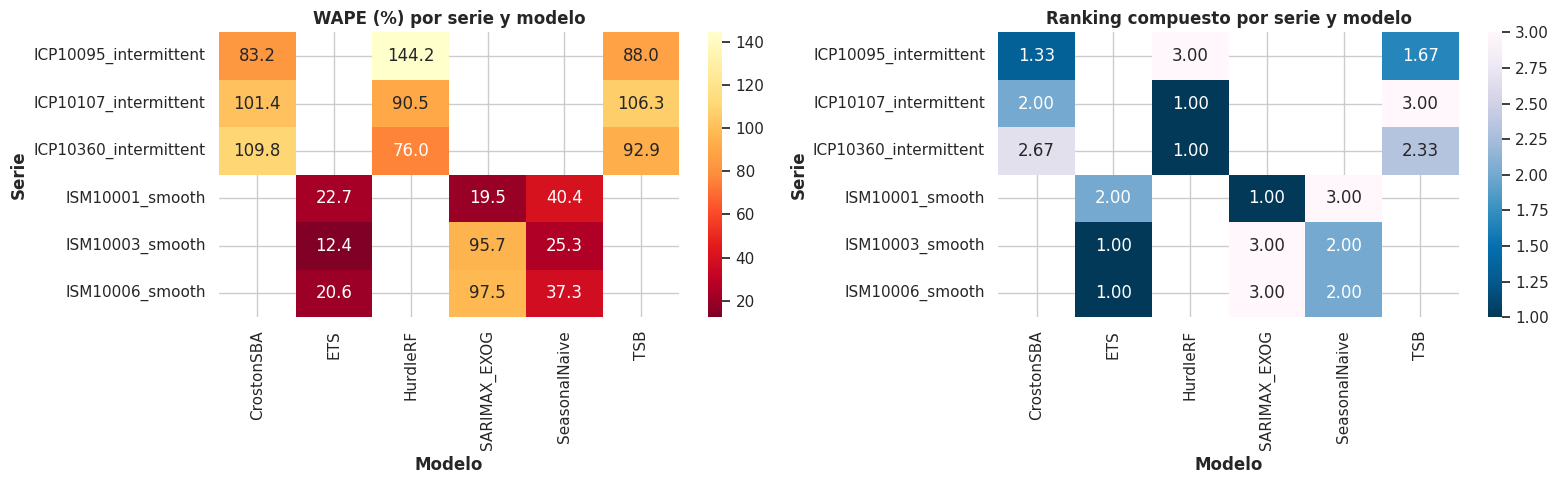

Backtesting y comparación de modelos ejecutados correctamente.


In [ ]:
# ============================================================
# SECCIÓN 3 | Ejecución del backtesting y tablas comparativas
# ============================================================
BACKTEST_STEPS = int(globals().get("ROLLING_TESTS", 12))
BACKTEST_STEPS = min(BACKTEST_STEPS, 12)

# ------------------------------------------------------------
# 1. Especificaciones SARIMAX por serie smooth
# ------------------------------------------------------------
smooth_specs = {}
for serie in SMOOTH_COLS:
    spec = infer_sarimax_spec(serie)
    smooth_specs[serie] = spec

smooth_specs_df = pd.DataFrame([
    {
        "serie": serie,
        "order": str(spec["order"]),
        "seasonal_order": str(spec["seasonal_order"]),
        "trend": spec["trend"],
    }
    for serie, spec in smooth_specs.items()
])

display(
    style_table(
        smooth_specs_df.style,
        "Especificación SARIMAX utilizada por serie smooth"
    )
)

# ------------------------------------------------------------
# 2. Backtesting rolling-origin
# ------------------------------------------------------------
all_predictions = []

for serie in SMOOTH_COLS:
    for model_name in SMOOTH_MODELS:
        pred_df = rolling_backtest_series(
            data=df,
            target=serie,
            model_name=model_name,
            family="smooth",
            n_test=BACKTEST_STEPS,
            sarimax_spec=smooth_specs.get(serie),
        )
        all_predictions.append(pred_df)

for serie in SPARSE_COLS:
    for model_name in SPARSE_MODELS:
        pred_df = rolling_backtest_series(
            data=df,
            target=serie,
            model_name=model_name,
            family="sparse",
            n_test=BACKTEST_STEPS,
            sarimax_spec=None,
        )
        all_predictions.append(pred_df)

backtest_predictions_df = pd.concat(all_predictions, ignore_index=True)

# ------------------------------------------------------------
# 3. Métricas por serie y modelo
# ------------------------------------------------------------
metric_rows = []

for (serie, family, model_name), grp in backtest_predictions_df.groupby(["serie", "family", "model"]):
    active = active_slice(df, serie).copy()
    n_test = len(grp)
    insample = active[serie].iloc[:-n_test].astype(float).to_numpy()
    seasonal_m = SEASONAL_PERIOD if family == "smooth" else 1

    metrics = compute_metrics(grp, insample=insample, seasonal_m=seasonal_m)

    metric_rows.append({
        "serie": serie,
        "family": family,
        "model": model_name,
        **metrics
    })

backtest_metrics_df = pd.DataFrame(metric_rows).sort_values(["serie", "WAPE_pct", "RMSE"]).reset_index(drop=True)

# ranking compuesto
backtest_metrics_df["rank_WAPE"] = backtest_metrics_df.groupby("serie")["WAPE_pct"].rank(method="dense")
backtest_metrics_df["rank_RMSE"] = backtest_metrics_df.groupby("serie")["RMSE"].rank(method="dense")
backtest_metrics_df["rank_MAE"] = backtest_metrics_df.groupby("serie")["MAE"].rank(method="dense")
backtest_metrics_df["rank_compuesto"] = (
    backtest_metrics_df["rank_WAPE"] +
    backtest_metrics_df["rank_RMSE"] +
    backtest_metrics_df["rank_MAE"]
) / 3.0

display(
    style_table(
        backtest_metrics_df.style
        .format({
            "MAE": "{:,.3f}",
            "RMSE": "{:,.3f}",
            "sMAPE_pct": "{:.2f}",
            "WAPE_pct": "{:.2f}",
            "MASE": "{:.3f}",
            "Bias_pct": "{:.2f}",
            "Activity_acc": "{:.2%}",
            "rank_compuesto": "{:.2f}",
        })
        .background_gradient(subset=["MAE", "RMSE", "sMAPE_pct", "WAPE_pct", "MASE"], cmap="YlOrRd_r")
        .background_gradient(subset=["Activity_acc"], cmap="Greens")
        .background_gradient(subset=["rank_compuesto"], cmap="PuBu_r"),
        "Métricas comparativas de backtesting por serie y modelo"
    )
)

# ------------------------------------------------------------
# 4. Ganador por serie
# ------------------------------------------------------------
best_models_df = (
    backtest_metrics_df
    .sort_values(["serie", "rank_compuesto", "WAPE_pct", "RMSE"])
    .groupby("serie", as_index=False)
    .first()
    .sort_values(["family", "serie"])
    .reset_index(drop=True)
)

display(
    style_table(
        best_models_df.style
        .format({
            "MAE": "{:,.3f}",
            "RMSE": "{:,.3f}",
            "sMAPE_pct": "{:.2f}",
            "WAPE_pct": "{:.2f}",
            "MASE": "{:.3f}",
            "Bias_pct": "{:.2f}",
            "Activity_acc": "{:.2%}",
            "rank_compuesto": "{:.2f}",
        })
        .background_gradient(subset=["WAPE_pct", "RMSE", "MAE"], cmap="YlOrRd_r")
        .background_gradient(subset=["Activity_acc"], cmap="Greens"),
        "Modelo seleccionado por serie según ranking compuesto"
    )
)

# ------------------------------------------------------------
# 5. Resumen por familia y modelo
# ------------------------------------------------------------
family_summary_df = (
    backtest_metrics_df
    .groupby(["family", "model"], as_index=False)
    .agg(
        series_evaluadas=("serie", "count"),
        WAPE_promedio=("WAPE_pct", "mean"),
        RMSE_promedio=("RMSE", "mean"),
        MAE_promedio=("MAE", "mean"),
        sMAPE_promedio=("sMAPE_pct", "mean"),
        rank_compuesto_promedio=("rank_compuesto", "mean"),
    )
    .sort_values(["family", "rank_compuesto_promedio", "WAPE_promedio"])
    .reset_index(drop=True)
)

display(
    style_table(
        family_summary_df.style
        .format({
            "WAPE_promedio": "{:.2f}",
            "RMSE_promedio": "{:,.3f}",
            "MAE_promedio": "{:,.3f}",
            "sMAPE_promedio": "{:.2f}",
            "rank_compuesto_promedio": "{:.2f}",
        })
        .background_gradient(subset=["WAPE_promedio", "RMSE_promedio", "MAE_promedio", "rank_compuesto_promedio"], cmap="YlOrRd_r"),
        "Resumen medio por familia de serie y modelo"
    )
)

# ------------------------------------------------------------
# 6. Mapas comparativos
# ------------------------------------------------------------
pivot_wape = backtest_metrics_df.pivot(index="serie", columns="model", values="WAPE_pct")
pivot_rank = backtest_metrics_df.pivot(index="serie", columns="model", values="rank_compuesto")

fig, axes = plt.subplots(1, 2, figsize=(16, 5))

sns.heatmap(pivot_wape, annot=True, fmt=".1f", cmap="YlOrRd_r", ax=axes[0])
axes[0].set_title("WAPE (%) por serie y modelo")
axes[0].set_xlabel("Modelo")
axes[0].set_ylabel("Serie")

sns.heatmap(pivot_rank, annot=True, fmt=".2f", cmap="PuBu_r", ax=axes[1])
axes[1].set_title("Ranking compuesto por serie y modelo")
axes[1].set_xlabel("Modelo")
axes[1].set_ylabel("Serie")

plt.tight_layout()
plt.show()

print("Backtesting y comparación de modelos ejecutados correctamente.")

# **4. Ajuste final del modelo ganador, pronóstico a 12 meses y traducción a política de inventario**

> **Propósito técnico.**  
> Esta sección reentrena el modelo seleccionado para cada SKU con toda la vida activa disponible y genera el pronóstico final a 12 meses. A partir de esas trayectorias futuras, se construyen bandas de incertidumbre y se traducen los resultados a parámetros preliminares de política de inventario, especialmente demanda esperada en lead time, stock de seguridad y punto de reorden.

---

## 4.1. Escenario base de variables exógenas futuras

Dado que las variables exógenas futuras no se observan directamente al momento de pronosticar, se adopta un escenario base parsimonioso:

| Variable | Regla de proyección | Lectura metodológica |
|---|---|---|
| **Temperatura media** | promedio histórico del mismo mes calendario | preserva la climatología mensual |
| **Precipitación** | promedio histórico del mismo mes calendario | conserva la estacionalidad típica |
| **TRM** | promedio reciente de los últimos meses | evita imponer una deriva arbitraria |

Para cada horizonte futuro $t+h$:

$$
\widehat{\text{Temp}}_{t+h} = \overline{\text{Temp}}_{m(h)}
$$

$$
\widehat{\text{Prec}}_{t+h} = \overline{\text{Prec}}_{m(h)}
$$

$$
\widehat{\text{TRM}}_{t+h} = \frac{1}{k}\sum_{j=0}^{k-1}\text{TRM}_{t-j}
$$

donde $m(h)$ representa el mes calendario del horizonte futuro y $k$ la ventana reciente usada para TRM.

---

## 4.2. Ajuste final por familia de demanda

### Series smooth

Las series smooth conservan el modelo ganador del backtesting y se reentrenan usando toda la vida activa. En el caso del bloque SARIMAX, la especificación se mantiene parsimoniosa pero suficientemente flexible para capturar oscilaciones y cambios de nivel.

### Series sparse

En series intermitentes se conserva la evidencia del backtesting, pero la proyección final incorpora un criterio adicional de representación estructural:

| Criterio | Interpretación |
|---|---|
| **Modelo ganador claro** | se conserva la arquitectura ganadora |
| **HurdleRF cercano al ganador** | se permite usarlo como refinamiento final por su mejor capacidad para reproducir ceros y pulsos |
| **Croston/TSB como proyección final** | la trayectoria puntual se convierte en una ruta intermitente operativa, no en una media plana |

Este ajuste evita que una buena métrica agregada termine produciendo una trayectoria visualmente incoherente para demanda esporádica.

---

## 4.3. Traducción a política de inventario

Sea $L$ el lead time medido en meses. La demanda acumulada esperada en ese horizonte se define como:

$$
\mu_L = \sum_{h=1}^{L}\hat{y}_{t+h}
$$

A partir de la distribución simulada de la demanda en lead time, el stock de seguridad y el punto de reorden se calculan como:

$$
SS = Q_{\alpha}(D_L) - \mathbb{E}[D_L]
$$

$$
ROP = Q_{\alpha}(D_L)
$$

donde:

| Símbolo | Interpretación |
|---|---|
| $D_L$ | demanda acumulada durante el lead time |
| $Q_{\alpha}(D_L)$ | cuantil asociado al nivel de servicio objetivo $\alpha$ |
| $SS$ | stock de seguridad |
| $ROP$ | punto de reorden |

---

## 4.4. Parámetros editables

| Parámetro | Función |
|---|---|
| **Lead time por SKU** | meses entre emisión y recepción |
| **Nivel de servicio por SKU** | probabilidad objetivo de no quiebre en lead time |
| **FAST_MODE** | modo de prueba rápida |
| **N_SIMS_SMOOTH** | simulaciones para series smooth |
| **N_SIMS_SPARSE** | simulaciones para Croston/TSB |
| **N_SIMS_HURDLE** | simulaciones recursivas para HurdleRF |
| **SPARSE_DYNAMIC_TOLERANCE** | tolerancia para activar refinamiento HurdleRF |

---

## 4.5. Salidas de la sección

| Salida | Finalidad |
|---|---|
| **Tabla de escenario exógeno futuro** | documentar supuestos del horizonte |
| **Tabla de decisión final de modelo** | diferenciar modelo ganador en métricas y modelo usado para proyección final |
| **Tabla de pronósticos finales** | consolidar medias e intervalos |
| **Tabla de política de inventario** | resumir demanda esperada, stock de seguridad y ROP |
| **Gráficos finales por SKU** | visualizar empalme entre histórico reciente y proyección |
| **Archivo Excel exportable** | facilitar revisión técnica y trazabilidad |

---

> **Nota metodológica.**  
> La parametrización obtenida constituye una base cuantitativa inicial. La adopción final debe ajustarse al lead time real de abastecimiento, criticidad operativa del repuesto, costos de quiebre, restricciones presupuestales y frecuencia efectiva de revisión del inventario.

In [ ]:
# ============================================================
# SECCIÓN 4 | Ajuste final, simulación y política de inventario
# VERSIÓN MEJORADA
# ============================================================
import warnings
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from IPython.display import display
from tqdm.notebook import tqdm
from scipy.stats import norm
from statsmodels.tsa.statespace.sarimax import SARIMAX
from statsmodels.tsa.holtwinters import ExponentialSmoothing
from sklearn.ensemble import RandomForestClassifier, RandomForestRegressor

warnings.filterwarnings("ignore")

# ------------------------------------------------------------
# Validación de objetos previos
# ------------------------------------------------------------
required_globals = [
    "df", "DATE_COL", "EXOG_COLS", "TARGET_COLS", "SEASONAL_PERIOD",
    "best_models_df"
]
missing_globals = [g for g in required_globals if g not in globals()]
if missing_globals:
    raise ValueError(f"Antes de ejecutar esta sección deben existir estas variables: {missing_globals}")

if "active_slice" not in globals():
    def active_slice(data, col):
        first_idx = data[col].first_valid_index()
        if first_idx is None:
            return data.iloc[0:0].copy()
        keep_cols = [DATE_COL, col] + EXOG_COLS
        return data.loc[first_idx:, keep_cols].reset_index(drop=True)

if "RANDOM_STATE" not in globals():
    RANDOM_STATE = 42

# ------------------------------------------------------------
# Parámetros editables
# ------------------------------------------------------------
FINAL_HORIZON = int(globals().get("FORECAST_HORIZON", 12))
TRM_RECENT_WINDOW = 6

FAST_MODE = True
SHOW_INNER_PROGRESS = True

umbral = 120 if FAST_MODE else 0
N_SIMS_SMOOTH = 350-umbral if FAST_MODE else 900
N_SIMS_SPARSE = 250-umbral if FAST_MODE else 800
N_SIMS_HURDLE = 180-umbral if FAST_MODE else 450

SARIMAX_MAXITER = 85
ETS_USE_BRUTE = False

RF_N_ESTIMATORS = 120 if FAST_MODE else 220
RF_MAX_DEPTH = 5 if FAST_MODE else 6
RF_MIN_LEAF = 3 if FAST_MODE else 2

SPARSE_DYNAMIC_TOLERANCE = 0.15   # si HurdleRF queda a <= 15% del WAPE del ganador, puede refinar la proyección final

DEFAULT_LEAD_TIME = 3
DEFAULT_SERVICE_LEVEL = 0.95

LEAD_TIME_BY_SKU = {serie: DEFAULT_LEAD_TIME for serie in TARGET_COLS}
SERVICE_LEVEL_BY_SKU = {serie: DEFAULT_SERVICE_LEVEL for serie in TARGET_COLS}

TEMP_DELTA = 0.0
PRECIP_MULT = 1.0
TRM_MULT = 1.0

# ------------------------------------------------------------
# Estilo de tablas
# ------------------------------------------------------------
def style_table(styler, caption):
    return (
        styler
        .set_caption(caption)
        .set_table_styles([
            {"selector": "caption", "props": [("font-size", "14px"), ("font-weight", "bold")]},
            {"selector": "th", "props": [("background-color", "#16324f"), ("color", "white"), ("text-align", "center")]},
            {"selector": "td", "props": [("text-align", "center")]},
        ])
    )

# ------------------------------------------------------------
# Escenario exógeno futuro
# ------------------------------------------------------------
def build_future_exog_base(data, horizon=12, trm_window=6):
    work = data[[DATE_COL] + EXOG_COLS].copy()
    work[DATE_COL] = pd.to_datetime(work[DATE_COL])

    last_date = work[DATE_COL].max()
    future_dates = pd.date_range(last_date + pd.offsets.MonthBegin(1), periods=horizon, freq="MS")

    work["month"] = work[DATE_COL].dt.month
    month_clim = work.groupby("month")[["temp_media_c", "precipitacion_mm"]].mean()

    temp_global = work["temp_media_c"].mean()
    prec_global = work["precipitacion_mm"].mean()
    month_clim["temp_media_c"] = month_clim["temp_media_c"].fillna(temp_global)
    month_clim["precipitacion_mm"] = month_clim["precipitacion_mm"].fillna(prec_global)

    recent_trm = work["trm_promedio"].dropna().tail(trm_window)
    trm_base = recent_trm.mean() if len(recent_trm) > 0 else work["trm_promedio"].dropna().mean()

    future = pd.DataFrame({DATE_COL: future_dates})
    future["month"] = future[DATE_COL].dt.month
    future["temp_media_c"] = future["month"].map(month_clim["temp_media_c"]).astype(float) + TEMP_DELTA
    future["precipitacion_mm"] = future["month"].map(month_clim["precipitacion_mm"]).astype(float) * PRECIP_MULT
    future["trm_promedio"] = float(trm_base) * TRM_MULT

    return future[[DATE_COL] + EXOG_COLS].copy()

future_exog_df = build_future_exog_base(df, horizon=FINAL_HORIZON, trm_window=TRM_RECENT_WINDOW)

display(
    style_table(
        future_exog_df.style.format({
            "temp_media_c": "{:.3f}",
            "precipitacion_mm": "{:.3f}",
            "trm_promedio": "{:,.3f}",
        }),
        "Escenario base de variables exógenas para el horizonte futuro"
    )
)

# ------------------------------------------------------------
# Utilidades generales
# ------------------------------------------------------------
rng_global = np.random.default_rng(RANDOM_STATE)

def normal_bounds(mean, sigma, level=0.95):
    z = norm.ppf((1 + level) / 2)
    lower = np.maximum(mean - z * sigma, 0)
    upper = np.maximum(mean + z * sigma, 0)
    return lower, upper

def pack_forecast_output(dates, pred, lower80, upper80, lower95, upper95, sim_paths):
    return {
        "dates": pd.to_datetime(dates),
        "pred": np.asarray(pred, dtype=float),
        "lower80": np.asarray(lower80, dtype=float),
        "upper80": np.asarray(upper80, dtype=float),
        "lower95": np.asarray(lower95, dtype=float),
        "upper95": np.asarray(upper95, dtype=float),
        "sim_paths": np.asarray(sim_paths, dtype=float),
    }

def fit_final_sarimax_spec(series_name):
    if "smooth_specs" in globals() and series_name in smooth_specs:
        return smooth_specs[series_name]

    d, D = 1, 1
    seasonal_strength = 0.0

    if "diagnostic_df" in globals():
        row = diagnostic_df.loc[diagnostic_df["serie"] == series_name]
        if not row.empty:
            d = int(row["d_sugerido"].iloc[0])
            D = int(row["D_sugerido"].iloc[0])
            seasonal_strength = float(row["seasonal_strength"].iloc[0]) if pd.notna(row["seasonal_strength"].iloc[0]) else 0.0

    order = (2, d, 1) if seasonal_strength >= 0.25 else (1, d, 1)
    seasonal_order = (1, D, 1, SEASONAL_PERIOD) if D == 1 else (0, 0, 0, SEASONAL_PERIOD)

    return {"order": order, "seasonal_order": seasonal_order, "trend": "c"}

# ------------------------------------------------------------
# Modelos smooth
# ------------------------------------------------------------
def final_forecast_seasonal_naive(active_df, target, horizon=12, n_sims=500):
    y = active_df[target].astype(float).reset_index(drop=True)
    dates = future_exog_df[DATE_COL].iloc[:horizon].to_numpy()

    if len(y) >= SEASONAL_PERIOD:
        pattern = y.iloc[-SEASONAL_PERIOD:].to_numpy(dtype=float)
        pred = np.array([pattern[i % SEASONAL_PERIOD] for i in range(horizon)], dtype=float)
        resid = (y - y.shift(SEASONAL_PERIOD)).dropna().to_numpy(dtype=float)
    else:
        pred = np.repeat(float(y.iloc[-1]), horizon)
        resid = (y - y.shift(1)).dropna().to_numpy(dtype=float)

    sigma_base = float(np.std(resid, ddof=1)) if len(resid) > 1 else float(max(y.std(ddof=1), 1.0))
    sigma = sigma_base * np.sqrt(np.arange(1, horizon + 1))

    lower80, upper80 = normal_bounds(pred, sigma, level=0.80)
    lower95, upper95 = normal_bounds(pred, sigma, level=0.95)

    sim_paths = rng_global.normal(loc=pred[None, :], scale=sigma[None, :], size=(n_sims, horizon))
    sim_paths = np.maximum(sim_paths, 0)

    return pack_forecast_output(dates, pred, lower80, upper80, lower95, upper95, sim_paths)

def final_forecast_ets(active_df, target, horizon=12, n_sims=500):
    y = active_df[target].astype(float).reset_index(drop=True)
    dates = future_exog_df[DATE_COL].iloc[:horizon].to_numpy()

    try:
        if len(y) >= 2 * SEASONAL_PERIOD:
            fit = ExponentialSmoothing(
                y,
                trend="add",
                damped_trend=True,
                seasonal="add",
                seasonal_periods=SEASONAL_PERIOD,
                initialization_method="estimated",
            ).fit(optimized=True, use_brute=ETS_USE_BRUTE)
        else:
            fit = ExponentialSmoothing(
                y,
                trend="add",
                damped_trend=True,
                seasonal=None,
                initialization_method="estimated",
            ).fit(optimized=True, use_brute=ETS_USE_BRUTE)

        pred = np.maximum(np.asarray(fit.forecast(horizon), dtype=float), 0)
        resid = np.asarray(fit.resid, dtype=float)
        sigma_base = float(np.std(resid, ddof=1)) if len(resid) > 1 else float(max(y.std(ddof=1), 1.0))
        sigma = sigma_base * np.sqrt(np.arange(1, horizon + 1))

        lower80, upper80 = normal_bounds(pred, sigma, level=0.80)
        lower95, upper95 = normal_bounds(pred, sigma, level=0.95)

        sim_paths = rng_global.normal(loc=pred[None, :], scale=sigma[None, :], size=(n_sims, horizon))
        sim_paths = np.maximum(sim_paths, 0)

        return pack_forecast_output(dates, pred, lower80, upper80, lower95, upper95, sim_paths)

    except Exception:
        return final_forecast_seasonal_naive(active_df, target, horizon=horizon, n_sims=n_sims)

def final_forecast_sarimax(active_df, target, future_exog, spec, horizon=12, n_sims=500):
    y = active_df[target].astype(float).reset_index(drop=True)
    X = active_df[EXOG_COLS].astype(float).reset_index(drop=True)
    Xf = future_exog[EXOG_COLS].astype(float).reset_index(drop=True)
    dates = future_exog[DATE_COL].iloc[:horizon].to_numpy()

    try:
        model = SARIMAX(
            y,
            exog=X,
            order=spec["order"],
            seasonal_order=spec["seasonal_order"],
            trend=spec["trend"],
            enforce_stationarity=False,
            enforce_invertibility=False,
            simple_differencing=True,
        )
        fit = model.fit(disp=False, maxiter=SARIMAX_MAXITER, method="lbfgs")
        pred_res = fit.get_forecast(steps=horizon, exog=Xf)

        pred = np.maximum(np.asarray(pred_res.predicted_mean, dtype=float), 0)

        ci80 = pred_res.conf_int(alpha=0.20)
        ci95 = pred_res.conf_int(alpha=0.05)

        lower80 = np.maximum(np.asarray(ci80.iloc[:, 0], dtype=float), 0)
        upper80 = np.maximum(np.asarray(ci80.iloc[:, 1], dtype=float), 0)
        lower95 = np.maximum(np.asarray(ci95.iloc[:, 0], dtype=float), 0)
        upper95 = np.maximum(np.asarray(ci95.iloc[:, 1], dtype=float), 0)

        sigma = np.maximum((upper95 - lower95) / (2 * norm.ppf(0.975)), 1e-6)
        sim_paths = rng_global.normal(loc=pred[None, :], scale=sigma[None, :], size=(n_sims, horizon))
        sim_paths = np.maximum(sim_paths, 0)

        return pack_forecast_output(dates, pred, lower80, upper80, lower95, upper95, sim_paths)

    except Exception:
        return final_forecast_ets(active_df, target, horizon=horizon, n_sims=n_sims)

# ------------------------------------------------------------
# Utilidades sparse
# ------------------------------------------------------------
def compute_sparse_month_profiles(active_df, target):
    work = active_df[[DATE_COL, target]].copy()
    work["month"] = pd.to_datetime(work[DATE_COL]).dt.month
    y = work[target].astype(float)

    overall_pos_rate = float((y > 0).mean()) if len(y) > 0 else 0.0
    if overall_pos_rate <= 0:
        pos_rate_month = pd.Series(1.0, index=range(1, 13))
    else:
        pos_rate_month = work.groupby("month")[target].apply(lambda s: (s > 0).mean())
        pos_rate_month = (pos_rate_month / overall_pos_rate).reindex(range(1, 13)).fillna(1.0).clip(0.60, 1.60)

    pos_vals = work.loc[work[target] > 0].copy()
    if pos_vals.empty:
        month_amt = pd.Series(0.0, index=range(1, 13))
    else:
        base_median = float(pos_vals[target].median())
        month_amt = pos_vals.groupby("month")[target].median().reindex(range(1, 13))
        month_amt = month_amt.fillna(base_median)

    return pos_rate_month, month_amt

def deterministic_intermittent_path(prob_path, amount_path, min_occ=0):
    prob_path = np.asarray(prob_path, dtype=float)
    amount_path = np.asarray(amount_path, dtype=float)

    expected_occ = int(np.round(prob_path.sum()))
    n_occ = max(min_occ, expected_occ)
    n_occ = int(np.clip(n_occ, 0, len(prob_path)))

    pred = np.zeros(len(prob_path), dtype=float)
    if n_occ > 0:
        idx = np.argsort(-prob_path)[:n_occ]
        pred[idx] = amount_path[idx]

    return pred

def simulate_sparse_prob_amount(y_hist, prob_path, amount_path, n_sims=500):
    y_hist = np.asarray(pd.Series(y_hist).fillna(0).astype(float))
    positive_vals = y_hist[y_hist > 0]

    if len(positive_vals) == 0:
        return np.zeros((n_sims, len(prob_path)))

    base_med = np.median(positive_vals)
    sim_paths = np.zeros((n_sims, len(prob_path)), dtype=float)

    for s in range(n_sims):
        occ = rng_global.binomial(1, np.clip(prob_path, 0, 1))
        sampled = rng_global.choice(positive_vals, size=len(prob_path), replace=True)
        scale = np.where(base_med > 1e-8, amount_path / base_med, 1.0)
        sim_paths[s, :] = np.maximum(occ * sampled * scale, 0)

    return sim_paths

# ------------------------------------------------------------
# Croston y TSB
# ------------------------------------------------------------
def fit_croston_sba_state(y, alpha_grid=(0.05, 0.10, 0.20, 0.30)):
    y = np.asarray(pd.Series(y).fillna(0).astype(float))
    if (y > 0).sum() == 0:
        return {"expected": 0.0, "p_active": 0.0, "amount_mean": 0.0}

    nz = np.where(y > 0)[0]
    first = nz[0]

    best = None
    best_mae = np.inf

    for alpha in alpha_grid:
        z = y[first]
        p = 1.0
        interval = 1
        errors = []

        for t in range(first + 1, len(y)):
            fc = (1 - alpha / 2.0) * (z / max(p, 1e-8))
            errors.append(abs(y[t] - fc))

            if y[t] > 0:
                z = z + alpha * (y[t] - z)
                p = p + alpha * (interval - p)
                interval = 1
            else:
                interval += 1

        mae = np.mean(errors) if errors else np.inf
        fc_last = (1 - alpha / 2.0) * (z / max(p, 1e-8))

        if mae < best_mae:
            best_mae = mae
            p_active = float(np.clip(1.0 / max(p, 1e-8), 0, 1))
            amount_mean = float(fc_last / max(p_active, 1e-8))
            best = {
                "expected": float(max(fc_last, 0)),
                "p_active": p_active,
                "amount_mean": float(max(amount_mean, 0)),
            }

    return best

def fit_tsb_state(y, alpha_d_grid=(0.05, 0.10, 0.20, 0.30), alpha_p_grid=(0.05, 0.10, 0.20, 0.30)):
    y = np.asarray(pd.Series(y).fillna(0).astype(float))
    if (y > 0).sum() == 0:
        return {"expected": 0.0, "p_active": 0.0, "amount_mean": 0.0}

    nz = np.where(y > 0)[0]
    first = nz[0]

    best = None
    best_mae = np.inf

    for alpha_d in alpha_d_grid:
        for alpha_p in alpha_p_grid:
            z = y[first]
            p = 1.0
            errors = []

            for t in range(first + 1, len(y)):
                fc = p * z
                errors.append(abs(y[t] - fc))

                if y[t] > 0:
                    z = z + alpha_d * (y[t] - z)
                    p = p + alpha_p * (1.0 - p)
                else:
                    p = p + alpha_p * (0.0 - p)

            mae = np.mean(errors) if errors else np.inf
            fc_last = p * z

            if mae < best_mae:
                best_mae = mae
                best = {
                    "expected": float(max(fc_last, 0)),
                    "p_active": float(np.clip(p, 0, 1)),
                    "amount_mean": float(max(z, 0)),
                }

    return best

def final_forecast_sparse_rate_model(active_df, target, model_name, future_exog, horizon=12, n_sims=500):
    y = active_df[target].astype(float).to_numpy()
    dates = future_exog[DATE_COL].iloc[:horizon].to_numpy()

    if model_name == "CrostonSBA":
        state = fit_croston_sba_state(y)
    else:
        state = fit_tsb_state(y)

    month_prob_profile, month_amt_profile = compute_sparse_month_profiles(active_df, target)
    future_months = pd.to_datetime(future_exog[DATE_COL].iloc[:horizon]).dt.month

    prob_path = np.array([
        np.clip(state["p_active"] * month_prob_profile.loc[m], 0.02, 0.95)
        for m in future_months
    ], dtype=float)

    amount_path = np.array([
        max(0.0, 0.65 * state["amount_mean"] + 0.35 * month_amt_profile.loc[m])
        for m in future_months
    ], dtype=float)

    # Ruta puntual intermitente en lugar de media plana
    min_occ = 1 if prob_path.sum() >= 0.85 else 0
    pred = deterministic_intermittent_path(prob_path, amount_path, min_occ=min_occ)

    sim_paths = simulate_sparse_prob_amount(y, prob_path, amount_path, n_sims=n_sims)

    lower80 = np.quantile(sim_paths, 0.10, axis=0)
    upper80 = np.quantile(sim_paths, 0.90, axis=0)
    lower95 = np.quantile(sim_paths, 0.025, axis=0)
    upper95 = np.quantile(sim_paths, 0.975, axis=0)

    return pack_forecast_output(dates, pred, lower80, upper80, lower95, upper95, sim_paths)

# ------------------------------------------------------------
# Hurdle RF
# ------------------------------------------------------------
def build_hurdle_training_frame(active_df, target):
    work = active_df[[DATE_COL, target] + EXOG_COLS].copy()
    y = work[target].astype(float)

    work["month"] = work[DATE_COL].dt.month.astype(int)
    work["trend"] = np.arange(len(work))

    for lag in [1, 2, 3, 6, 12]:
        work[f"lag_{lag}"] = y.shift(lag)

    work["roll_mean_3"] = y.shift(1).rolling(3).mean()
    work["roll_mean_6"] = y.shift(1).rolling(6).mean()
    work["roll_nz_6"] = (y.shift(1) > 0).rolling(6).mean()
    work["target"] = y

    feature_cols = EXOG_COLS + [
        "month", "trend",
        "lag_1", "lag_2", "lag_3", "lag_6", "lag_12",
        "roll_mean_3", "roll_mean_6", "roll_nz_6"
    ]

    model_df = work.dropna(subset=feature_cols + ["target"]).reset_index(drop=True)
    return model_df, feature_cols

def build_hurdle_feature_row(y_hist, future_date, future_exog_dict):
    y_hist = np.asarray(y_hist, dtype=float)

    row = {k: float(v) for k, v in future_exog_dict.items()}
    row["month"] = int(pd.Timestamp(future_date).month)
    row["trend"] = int(len(y_hist))

    for lag in [1, 2, 3, 6, 12]:
        row[f"lag_{lag}"] = float(y_hist[-lag]) if len(y_hist) >= lag else np.nan

    row["roll_mean_3"] = float(np.mean(y_hist[-3:])) if len(y_hist) >= 3 else np.nan
    row["roll_mean_6"] = float(np.mean(y_hist[-6:])) if len(y_hist) >= 6 else np.nan
    row["roll_nz_6"] = float(np.mean(y_hist[-6:] > 0)) if len(y_hist) >= 6 else np.nan

    return pd.DataFrame([row])

def fit_hurdle_rf(active_df, target):
    model_df, feature_cols = build_hurdle_training_frame(active_df, target)
    if model_df.empty:
        return None

    X = model_df[feature_cols]
    y = model_df["target"].astype(float)
    y_bin = (y > 0).astype(int)

    if len(X) < 18 or y_bin.nunique() < 2 or y_bin.sum() < 4:
        return None

    clf = RandomForestClassifier(
        n_estimators=RF_N_ESTIMATORS,
        max_depth=RF_MAX_DEPTH,
        min_samples_leaf=RF_MIN_LEAF,
        class_weight="balanced_subsample",
        random_state=RANDOM_STATE,
        n_jobs=-1,
    )
    clf.fit(X, y_bin)

    reg = RandomForestRegressor(
        n_estimators=RF_N_ESTIMATORS,
        max_depth=RF_MAX_DEPTH,
        min_samples_leaf=RF_MIN_LEAF,
        random_state=RANDOM_STATE,
        n_jobs=-1,
    )
    reg.fit(X.loc[y > 0], y.loc[y > 0])

    resid_pos = (y.loc[y > 0] - reg.predict(X.loc[y > 0])).to_numpy(dtype=float)
    threshold = float(np.clip(y_bin.mean(), 0.35, 0.60))

    return {
        "clf": clf,
        "reg": reg,
        "feature_cols": feature_cols,
        "threshold": threshold,
        "resid_pos": resid_pos if len(resid_pos) > 0 else np.array([0.0]),
    }

def hurdle_recursive_point(active_df, target, future_exog, fitted_obj):
    y_hist = active_df[target].astype(float).to_numpy()
    preds = []

    for _, row in future_exog.iterrows():
        future_dict = {col: row[col] for col in EXOG_COLS}
        x_future = build_hurdle_feature_row(y_hist, row[DATE_COL], future_dict)

        if x_future[fitted_obj["feature_cols"]].isna().any().any():
            pred = 0.0
        else:
            prob = fitted_obj["clf"].predict_proba(x_future[fitted_obj["feature_cols"]])[0, 1]
            amt = max(float(fitted_obj["reg"].predict(x_future[fitted_obj["feature_cols"]])[0]), 0.0)
            pred = float((prob >= fitted_obj["threshold"]) * amt)

        preds.append(pred)
        y_hist = np.append(y_hist, pred)

    return np.asarray(preds, dtype=float)

def hurdle_recursive_sim(active_df, target, future_exog, fitted_obj, n_sims=300, show_progress=False):
    horizon = len(future_exog)
    sim_paths = np.zeros((n_sims, horizon), dtype=float)

    iterator = range(n_sims)
    if show_progress:
        iterator = tqdm(iterator, desc=f"Simulaciones HurdleRF | {target}", leave=False)

    base_hist = active_df[target].astype(float).to_numpy()

    for s in iterator:
        y_hist = base_hist.copy()

        for h, (_, row) in enumerate(future_exog.iterrows()):
            future_dict = {col: row[col] for col in EXOG_COLS}
            x_future = build_hurdle_feature_row(y_hist, row[DATE_COL], future_dict)

            if x_future[fitted_obj["feature_cols"]].isna().any().any():
                value = 0.0
            else:
                prob = fitted_obj["clf"].predict_proba(x_future[fitted_obj["feature_cols"]])[0, 1]
                amt = max(float(fitted_obj["reg"].predict(x_future[fitted_obj["feature_cols"]])[0]), 0.0)
                active_flag = rng_global.binomial(1, np.clip(prob, 0, 1))
                noise = rng_global.choice(fitted_obj["resid_pos"]) if active_flag == 1 else 0.0
                value = max(0.0, amt + noise) if active_flag == 1 else 0.0

            sim_paths[s, h] = value
            y_hist = np.append(y_hist, value)

    return sim_paths

def final_forecast_hurdle(active_df, target, future_exog, horizon=12, n_sims=300):
    fitted_obj = fit_hurdle_rf(active_df, target)
    if fitted_obj is None:
        return final_forecast_sparse_rate_model(active_df, target, "TSB", future_exog, horizon=horizon, n_sims=n_sims)

    dates = future_exog[DATE_COL].iloc[:horizon].to_numpy()
    pred = hurdle_recursive_point(active_df, target, future_exog.iloc[:horizon], fitted_obj)
    sim_paths = hurdle_recursive_sim(
        active_df,
        target,
        future_exog.iloc[:horizon],
        fitted_obj,
        n_sims=n_sims,
        show_progress=SHOW_INNER_PROGRESS
    )

    lower80 = np.quantile(sim_paths, 0.10, axis=0)
    upper80 = np.quantile(sim_paths, 0.90, axis=0)
    lower95 = np.quantile(sim_paths, 0.025, axis=0)
    upper95 = np.quantile(sim_paths, 0.975, axis=0)

    return pack_forecast_output(dates, pred, lower80, upper80, lower95, upper95, sim_paths)

# ------------------------------------------------------------
# Decisión final de modelo para proyección
# ------------------------------------------------------------
def choose_projection_model_for_sparse(serie, winner_model, tolerance=0.15):
    if "backtest_metrics_df" not in globals():
        return winner_model, "Sin backtest_metrics_df"

    sub = backtest_metrics_df[backtest_metrics_df["serie"] == serie].copy()
    if sub.empty or "model" not in sub.columns or "WAPE_pct" not in sub.columns:
        return winner_model, "Sin detalle de métricas"

    winner_row = sub[sub["model"] == winner_model]
    hurdle_row = sub[sub["model"] == "HurdleRF"]

    if winner_row.empty or hurdle_row.empty:
        return winner_model, "Sin comparación HurdleRF"

    winner_wape = float(winner_row["WAPE_pct"].iloc[0])
    hurdle_wape = float(hurdle_row["WAPE_pct"].iloc[0])

    if winner_model != "HurdleRF" and hurdle_wape <= winner_wape * (1 + tolerance):
        return "HurdleRF", f"HurdleRF dentro de tolerancia {tolerance:.0%} del ganador"
    else:
        return winner_model, "Se conserva ganador del backtesting"

best_model_lookup = best_models_df.set_index("serie")["model"].to_dict()
family_lookup = best_models_df.set_index("serie")["family"].to_dict()

decision_rows = []
projection_model_lookup = {}

for serie in TARGET_COLS:
    family = family_lookup[serie]
    backtest_winner = best_model_lookup[serie]

    if family == "sparse":
        projection_model, decision_note = choose_projection_model_for_sparse(
            serie,
            backtest_winner,
            tolerance=SPARSE_DYNAMIC_TOLERANCE
        )
    else:
        projection_model = backtest_winner
        decision_note = "Se conserva modelo ganador"

    projection_model_lookup[serie] = projection_model

    winner_wape = np.nan
    proj_wape = np.nan
    if "backtest_metrics_df" in globals():
        sub = backtest_metrics_df[backtest_metrics_df["serie"] == serie]
        if not sub.empty:
            row_w = sub[sub["model"] == backtest_winner]
            row_p = sub[sub["model"] == projection_model]
            if not row_w.empty:
                winner_wape = float(row_w["WAPE_pct"].iloc[0])
            if not row_p.empty:
                proj_wape = float(row_p["WAPE_pct"].iloc[0])

    decision_rows.append({
        "serie": serie,
        "family": family,
        "modelo_backtest_ganador": backtest_winner,
        "WAPE_backtest_ganador": winner_wape,
        "modelo_proyeccion_final": projection_model,
        "WAPE_modelo_proyeccion": proj_wape,
        "criterio": decision_note,
    })

final_model_decision_df = pd.DataFrame(decision_rows).sort_values(["family", "serie"]).reset_index(drop=True)

display(
    style_table(
        final_model_decision_df.style.format({
            "WAPE_backtest_ganador": "{:.2f}",
            "WAPE_modelo_proyeccion": "{:.2f}",
        }),
        "Decisión final de modelo para la proyección operativa"
    )
)

# ------------------------------------------------------------
# Ajuste final por serie con barra de progreso
# ------------------------------------------------------------
final_results = {}
final_forecast_rows = []
inventory_rows = []

progress = tqdm(TARGET_COLS, desc="Ajuste final por serie", leave=True)

for serie in progress:
    family = family_lookup[serie]
    model_name = projection_model_lookup[serie]
    progress.set_postfix_str(f"{serie} | {family} | {model_name}")

    active = active_slice(df, serie).copy()

    if family == "smooth":
        if model_name == "SARIMAX_EXOG":
            spec = fit_final_sarimax_spec(serie)
            out = final_forecast_sarimax(active, serie, future_exog_df, spec, horizon=FINAL_HORIZON, n_sims=N_SIMS_SMOOTH)
        elif model_name == "ETS":
            out = final_forecast_ets(active, serie, horizon=FINAL_HORIZON, n_sims=N_SIMS_SMOOTH)
        else:
            out = final_forecast_seasonal_naive(active, serie, horizon=FINAL_HORIZON, n_sims=N_SIMS_SMOOTH)
    else:
        if model_name == "HurdleRF":
            out = final_forecast_hurdle(active, serie, future_exog_df, horizon=FINAL_HORIZON, n_sims=N_SIMS_HURDLE)
        elif model_name in ["CrostonSBA", "TSB"]:
            out = final_forecast_sparse_rate_model(active, serie, model_name, future_exog_df, horizon=FINAL_HORIZON, n_sims=N_SIMS_SPARSE)
        else:
            out = final_forecast_hurdle(active, serie, future_exog_df, horizon=FINAL_HORIZON, n_sims=N_SIMS_HURDLE)

    final_results[serie] = {
        "family": family,
        "model": model_name,
        "backtest_winner": best_model_lookup[serie],
        **out
    }

    for i, dt in enumerate(out["dates"]):
        final_forecast_rows.append({
            "serie": serie,
            "family": family,
            "modelo_backtest_ganador": best_model_lookup[serie],
            "modelo_proyeccion_final": model_name,
            "fecha": pd.to_datetime(dt),
            "pred": float(out["pred"][i]),
            "lower80": float(out["lower80"][i]),
            "upper80": float(out["upper80"][i]),
            "lower95": float(out["lower95"][i]),
            "upper95": float(out["upper95"][i]),
        })

    lead_time = int(LEAD_TIME_BY_SKU.get(serie, DEFAULT_LEAD_TIME))
    service = float(SERVICE_LEVEL_BY_SKU.get(serie, DEFAULT_SERVICE_LEVEL))
    lt_demand = out["sim_paths"][:, :lead_time].sum(axis=1)

    mean_lt = float(np.mean(lt_demand))
    p50_lt = float(np.quantile(lt_demand, 0.50))
    p_service = float(np.quantile(lt_demand, service))
    safety_stock = float(max(p_service - mean_lt, 0))
    reorder_point = float(max(p_service, 0))

    inventory_rows.append({
        "serie": serie,
        "family": family,
        "modelo_backtest_ganador": best_model_lookup[serie],
        "modelo_proyeccion_final": model_name,
        "lead_time_meses": lead_time,
        "service_level": service,
        "forecast_12m_total": float(out["pred"].sum()),
        "forecast_promedio_mensual": float(out["pred"].mean()),
        "mean_lt_demand": mean_lt,
        "p50_lt_demand": p50_lt,
        "service_quantile_lt": p_service,
        "safety_stock": safety_stock,
        "reorder_point": reorder_point,
    })

final_forecast_df = pd.DataFrame(final_forecast_rows).sort_values(["serie", "fecha"]).reset_index(drop=True)
inventory_policy_df = pd.DataFrame(inventory_rows).sort_values(["family", "serie"]).reset_index(drop=True)

display(
    style_table(
        final_forecast_df.head(24).style.format({
            "pred": "{:,.3f}",
            "lower80": "{:,.3f}",
            "upper80": "{:,.3f}",
            "lower95": "{:,.3f}",
            "upper95": "{:,.3f}",
        }),
        "Pronósticos finales por serie y horizonte (muestra inicial)"
    )
)

display(
    style_table(
        inventory_policy_df.style
        .format({
            "service_level": "{:.0%}",
            "forecast_12m_total": "{:,.3f}",
            "forecast_promedio_mensual": "{:,.3f}",
            "mean_lt_demand": "{:,.3f}",
            "p50_lt_demand": "{:,.3f}",
            "service_quantile_lt": "{:,.3f}",
            "safety_stock": "{:,.3f}",
            "reorder_point": "{:,.3f}",
        })
        .background_gradient(subset=["forecast_12m_total", "mean_lt_demand", "reorder_point"], cmap="PuBu")
        .background_gradient(subset=["safety_stock"], cmap="YlOrRd"),
        "Parámetros preliminares de política de inventario por SKU"
    )
)

output_path = Path("/content/resultados_finales_inventario.xlsx")
with pd.ExcelWriter(output_path, engine="openpyxl") as writer:
    future_exog_df.to_excel(writer, sheet_name="escenario_exogeno", index=False)
    final_model_decision_df.to_excel(writer, sheet_name="decision_modelo_final", index=False)
    final_forecast_df.to_excel(writer, sheet_name="pronosticos_finales", index=False)
    inventory_policy_df.to_excel(writer, sheet_name="politica_inventario", index=False)
    best_models_df.to_excel(writer, sheet_name="modelos_ganadores", index=False)

print(f"Archivo exportado: {output_path}")
print(f"FAST_MODE = {FAST_MODE}")
print(f"N_SIMS_SMOOTH = {N_SIMS_SMOOTH}")
print(f"N_SIMS_SPARSE = {N_SIMS_SPARSE}")
print(f"N_SIMS_HURDLE = {N_SIMS_HURDLE}")
print(f"SPARSE_DYNAMIC_TOLERANCE = {SPARSE_DYNAMIC_TOLERANCE}")
print(f"SHOW_INNER_PROGRESS = {SHOW_INNER_PROGRESS}")
print("Bloque principal de la Sección 4 ejecutado correctamente.")

,fecha,temp_media_c,precipitacion_mm,trm_promedio
0,2026-01-01 00:00:00,12.629,33.848,"3,908.416"
1,2026-02-01 00:00:00,13.244,71.367,"3,908.416"
2,2026-03-01 00:00:00,13.304,126.157,"3,908.416"
3,2026-04-01 00:00:00,13.243,131.762,"3,908.416"
4,2026-05-01 00:00:00,13.249,97.352,"3,908.416"
5,2026-06-01 00:00:00,12.670,73.852,"3,908.416"
6,2026-07-01 00:00:00,12.520,38.210,"3,908.416"
7,2026-08-01 00:00:00,12.574,43.957,"3,908.416"
8,2026-09-01 00:00:00,12.792,53.386,"3,908.416"
9,2026-10-01 00:00:00,12.828,92.167,"3,908.416"


,serie,family,modelo_backtest_ganador,WAPE_backtest_ganador,modelo_proyeccion_final,WAPE_modelo_proyeccion,criterio
0,ISM10001_smooth,smooth,SARIMAX_EXOG,19.48,SARIMAX_EXOG,19.48,Se conserva modelo ganador
1,ISM10003_smooth,smooth,ETS,12.43,ETS,12.43,Se conserva modelo ganador
2,ISM10006_smooth,smooth,ETS,20.64,ETS,20.64,Se conserva modelo ganador
3,ICP10095_intermittent,sparse,CrostonSBA,83.16,CrostonSBA,83.16,Se conserva ganador del backtesting
4,ICP10107_intermittent,sparse,HurdleRF,90.47,HurdleRF,90.47,Se conserva ganador del backtesting
5,ICP10360_intermittent,sparse,HurdleRF,76.02,HurdleRF,76.02,Se conserva ganador del backtesting


Ajuste final por serie:   0%|          | 0/6 [00:00<?, ?it/s]

Simulaciones HurdleRF | ICP10107_intermittent:   0%|          | 0/60 [00:00<?, ?it/s]

Simulaciones HurdleRF | ICP10360_intermittent:   0%|          | 0/60 [00:00<?, ?it/s]

,serie,family,modelo_backtest_ganador,modelo_proyeccion_final,fecha,pred,lower80,upper80,lower95,upper95
0,ICP10095_intermittent,sparse,CrostonSBA,CrostonSBA,2026-01-01 00:00:00,0.000,0.000,3.676,0.000,7.352
1,ICP10095_intermittent,sparse,CrostonSBA,CrostonSBA,2026-02-01 00:00:00,4.157,1.386,11.086,0.000,16.629
2,ICP10095_intermittent,sparse,CrostonSBA,CrostonSBA,2026-03-01 00:00:00,3.107,0.000,4.143,0.000,8.286
3,ICP10095_intermittent,sparse,CrostonSBA,CrostonSBA,2026-04-01 00:00:00,2.582,0.861,6.886,0.000,10.329
4,ICP10095_intermittent,sparse,CrostonSBA,CrostonSBA,2026-05-01 00:00:00,2.407,0.000,3.210,0.000,6.419
5,ICP10095_intermittent,sparse,CrostonSBA,CrostonSBA,2026-06-01 00:00:00,0.000,0.000,4.143,0.000,8.286
6,ICP10095_intermittent,sparse,CrostonSBA,CrostonSBA,2026-07-01 00:00:00,2.407,0.000,3.210,0.000,8.906
7,ICP10095_intermittent,sparse,CrostonSBA,CrostonSBA,2026-08-01 00:00:00,0.000,0.000,4.143,0.000,8.286
8,ICP10095_intermittent,sparse,CrostonSBA,CrostonSBA,2026-09-01 00:00:00,3.282,0.000,6.564,0.000,13.129
9,ICP10095_intermittent,sparse,CrostonSBA,CrostonSBA,2026-10-01 00:00:00,0.000,0.000,4.814,0.000,8.906


,serie,family,modelo_backtest_ganador,modelo_proyeccion_final,lead_time_meses,service_level,forecast_12m_total,forecast_promedio_mensual,mean_lt_demand,p50_lt_demand,service_quantile_lt,safety_stock,reorder_point
0,ISM10001_smooth,smooth,SARIMAX_EXOG,SARIMAX_EXOG,3,95%,932.752,77.729,253.411,255.650,319.035,65.625,319.035
1,ISM10003_smooth,smooth,ETS,ETS,3,95%,"5,892.942",491.079,"1,482.954","1,469.677","1,917.717",434.763,"1,917.717"
2,ISM10006_smooth,smooth,ETS,ETS,3,95%,"45,060.207","3,755.017","11,158.205","11,322.606","14,730.079","3,571.874","14,730.079"
3,ICP10095_intermittent,sparse,CrostonSBA,CrostonSBA,3,95%,23.632,1.969,8.252,7.148,17.498,9.246,17.498
4,ICP10107_intermittent,sparse,HurdleRF,HurdleRF,3,95%,950.530,79.211,183.434,196.586,358.639,175.206,358.639
5,ICP10360_intermittent,sparse,HurdleRF,HurdleRF,3,95%,35.516,2.960,5.052,5.164,8.572,3.521,8.572


Archivo exportado: /content/resultados_finales_inventario.xlsx
FAST_MODE = True
N_SIMS_SMOOTH = 230
N_SIMS_SPARSE = 130
N_SIMS_HURDLE = 60
SPARSE_DYNAMIC_TOLERANCE = 0.15
SHOW_INNER_PROGRESS = True
Bloque principal de la Sección 4 ejecutado correctamente.


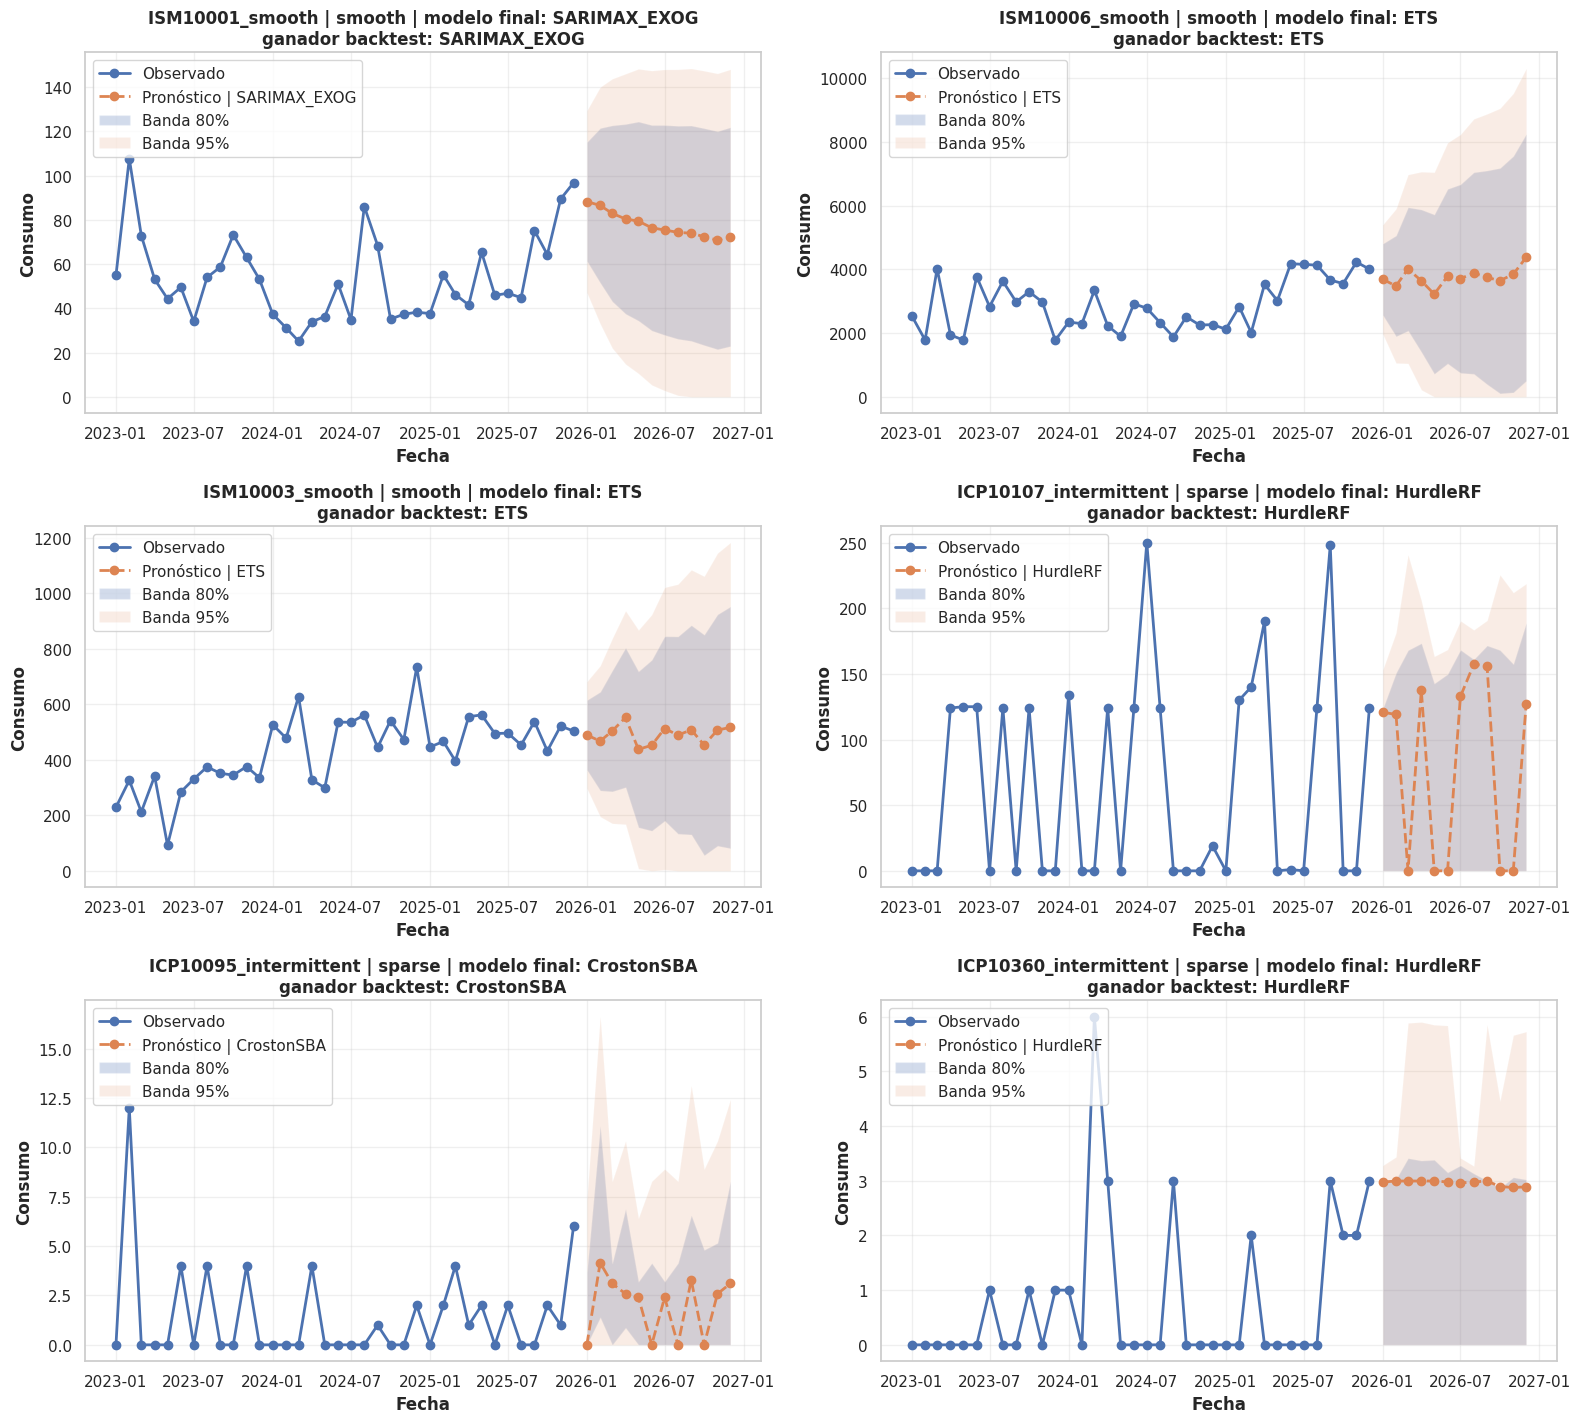

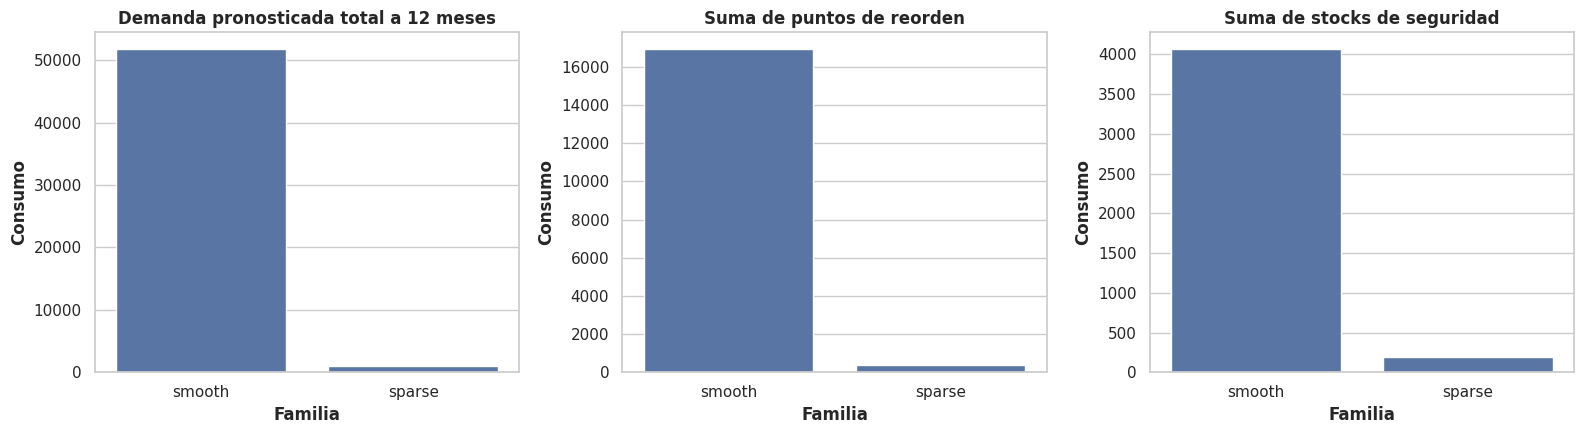

,serie,family,modelo_backtest_ganador,modelo_proyeccion_final,lead_time_meses,service_level,forecast_12m_total,forecast_promedio_mensual,safety_stock,reorder_point
0,ISM10001_smooth,smooth,SARIMAX_EXOG,SARIMAX_EXOG,3,95%,932.752,77.729,65.625,319.035
1,ISM10003_smooth,smooth,ETS,ETS,3,95%,"5,892.942",491.079,434.763,"1,917.717"
2,ISM10006_smooth,smooth,ETS,ETS,3,95%,"45,060.207","3,755.017","3,571.874","14,730.079"
3,ICP10095_intermittent,sparse,CrostonSBA,CrostonSBA,3,95%,23.632,1.969,9.246,17.498
4,ICP10107_intermittent,sparse,HurdleRF,HurdleRF,3,95%,950.530,79.211,175.206,358.639
5,ICP10360_intermittent,sparse,HurdleRF,HurdleRF,3,95%,35.516,2.960,3.521,8.572


Archivo disponible en: /content/resultados_finales_inventario.xlsx
Bloque gráfico final ejecutado correctamente.


In [ ]:
# ============================================================
# SECCIÓN 4 | Gráficos finales y resumen ejecutivo
# ============================================================
n_series = len(TARGET_COLS)
ncols = 2
nrows = int(np.ceil(n_series / ncols))

fig, axes = plt.subplots(nrows, ncols, figsize=(16, 4.8 * nrows), squeeze=False)
axes = axes.flatten()

for ax, serie in zip(axes, TARGET_COLS):
    active = active_slice(df, serie).copy()
    out = final_results[serie]

    hist_n = 36
    hist_plot = active.tail(min(hist_n, len(active))).copy()

    ax.plot(
        hist_plot[DATE_COL], hist_plot[serie],
        marker="o", linewidth=2, label="Observado"
    )

    ax.plot(
        out["dates"], out["pred"],
        marker="o", linewidth=2, linestyle="--", label=f"Pronóstico | {out['model']}"
    )

    ax.fill_between(
        out["dates"], out["lower80"], out["upper80"],
        alpha=0.25, label="Banda 80%"
    )

    ax.fill_between(
        out["dates"], out["lower95"], out["upper95"],
        alpha=0.15, label="Banda 95%"
    )

    ax.set_title(
        f"{serie} | {out['family']} | modelo final: {out['model']}\n"
        f"ganador backtest: {out['backtest_winner']}"
    )
    ax.set_xlabel("Fecha")
    ax.set_ylabel("Consumo")
    ax.legend(loc="upper left")
    ax.grid(alpha=0.30)

for j in range(len(TARGET_COLS), len(axes)):
    axes[j].axis("off")

plt.tight_layout()
plt.show()

# ------------------------------------------------------------
# Resumen agregado por familia
# ------------------------------------------------------------
agg_plot_df = (
    inventory_policy_df.groupby("family", as_index=False)
    .agg(
        forecast_12m_total=("forecast_12m_total", "sum"),
        reorder_point_total=("reorder_point", "sum"),
        safety_stock_total=("safety_stock", "sum")
    )
)

fig, axes = plt.subplots(1, 3, figsize=(16, 4.5))

sns.barplot(data=agg_plot_df, x="family", y="forecast_12m_total", ax=axes[0])
axes[0].set_title("Demanda pronosticada total a 12 meses")
axes[0].set_xlabel("Familia")
axes[0].set_ylabel("Consumo")

sns.barplot(data=agg_plot_df, x="family", y="reorder_point_total", ax=axes[1])
axes[1].set_title("Suma de puntos de reorden")
axes[1].set_xlabel("Familia")
axes[1].set_ylabel("Consumo")

sns.barplot(data=agg_plot_df, x="family", y="safety_stock_total", ax=axes[2])
axes[2].set_title("Suma de stocks de seguridad")
axes[2].set_xlabel("Familia")
axes[2].set_ylabel("Consumo")

plt.tight_layout()
plt.show()

# ------------------------------------------------------------
# Tabla final compacta
# ------------------------------------------------------------
summary_final_df = inventory_policy_df[[
    "serie", "family", "modelo_backtest_ganador", "modelo_proyeccion_final",
    "lead_time_meses", "service_level",
    "forecast_12m_total", "forecast_promedio_mensual",
    "safety_stock", "reorder_point"
]].copy()

display(
    style_table(
        summary_final_df.style.format({
            "service_level": "{:.0%}",
            "forecast_12m_total": "{:,.3f}",
            "forecast_promedio_mensual": "{:,.3f}",
            "safety_stock": "{:,.3f}",
            "reorder_point": "{:,.3f}",
        })
        .background_gradient(subset=["forecast_12m_total", "reorder_point"], cmap="PuBu")
        .background_gradient(subset=["safety_stock"], cmap="YlOrRd"),
        "Resumen ejecutivo de pronóstico final y política sugerida"
    )
)

print(f"Archivo disponible en: /content/resultados_finales_inventario.xlsx")
print("Bloque gráfico final ejecutado correctamente.")